# 🏢 Şirket Analizi Notebook'u

## Amaç

Bu notebook, **Borsa İstanbul (BIST)** hisselerinden herhangi biri için derinlemesine finansal analiz yapmak amacıyla geliştirilmiştir. Tek bir şirketin çeyreklik/yıllık finansal verileri işlenerek; büyüme, karlılık, likidite, bilanço sağlığı, değerleme ve istatistiksel tahmin analizleri sunulmaktadır.

---

## Neler Analiz Edilir?

| Kategori | İçerik |
|---|---|
| **Büyüme** | Çeyreklik (QoQ) ve yıllık (YoY) gelir, kâr ve varlık büyüme oranları |
| **Karlılık** | Brüt kâr, FAVÖK, net kâr marjları; ROE, ROA, ROIC |
| **Bilanço** | Aktif-pasif yapısı, toplam borçlar, özkaynaklar, net işletme sermayesi |
| **Likidite** | Cari oran, asit-test oranı, net borç / FAVÖK |
| **Verimlilik** | Alacak tahsil süresi, stok devir hızı, aktif devir hızı |
| **Nakit Akışı** | İşletme, yatırım ve finansman nakit akımları; serbest nakit akımı |
| **Değerleme** | F/K, FD/FAVÖK, PD/DD çarpanları; istatistiksel model ile gelecek dönem tahmini |
| **Skor Kartı** | Her kategori için hesaplanan bileşik skor ve genel finansal sinyal |

---

## Nasıl Çalışır?

1. Hisse kodu girilir (örn. `THYAO`, `ASTOR`, `CIMSA`).
2. İstatistiksel değerleme yapılıp yapılmayacağı seçilir (`EVET` / `HAYIR`).
3. Eğer değerleme `EVET` seçildiyse, tahminlerde TÜFE kullanılıp kullanılmayacağı sorulur.
4. Finansal veriler `balancesheet` ve `yfinance` ile çekilir; oranlar hesaplanır; tablolar ve görseller üretilir.

---

## EVDS API Anahtarı

EVDS (Elektronik Veri Dağıtım Sistemi), Türkiye Cumhuriyet Merkez Bankası'nın (TCMB) makroekonomik veri platformudur. **TÜFE (Tüketici Fiyat Endeksi)** verisi bu platform üzerinden çekilmektedir.

### API Anahtarı Ne Zaman Gereklidir?

| İstatistiksel Değerleme | Tahminlerde TÜFE | API Anahtarı |
|---|---|---|
| HAYIR | — | ❌ Gerekmez |
| EVET | HAYIR | ❌ Gerekmez |
| EVET | **EVET** | ✅ **Zorunlu** |

> Tahminlerde TÜFE kullanılırsa EVDS geçmiş verisi, canlı TÜFE tahmini ve SARIMAX_EXOG devreye girer; kullanılmazsa yalnızca tek değişkenli modeller denenir.

### API Anahtarı Nasıl Alınır?

1. [https://evds2.tcmb.gov.tr](https://evds2.tcmb.gov.tr) adresine gidin.
2. Sağ üst köşeden **Üye Ol** / **Login** bağlantısına tıklayın.
3. Kayıt olduktan ve giriş yaptıktan sonra profil sayfanıza gidin.
4. **"API Anahtarı"** bölümünden anahtarınızı oluşturun ve kopyalayın.

### API Anahtarı Kodda Nerede Kullanılır?

Bu notebook içinde API anahtarı aşağıdaki iki fonksiyona parametre olarak iletilmektedir:

```python
# Fonksiyon tanımları — api_key parametresi olarak alınır:
def TUFE_alma(df, api_key):
    evds = evdsAPI(api_key)          # ← API anahtarı burada kullanılır
    ...

def TUFE_alma_2(df, api_key):
    evds = evdsAPI(api_key)          # ← API anahtarı burada kullanılır
    ...
```

Notebook'u doğrudan çalıştırırken API anahtarınızı aşağıdaki gibi tanımlayabilirsiniz:

```python
# PowerShell: $env:EVDS_API_KEY="anahtarınız"
api_key = os.getenv("EVDS_API_KEY")
```

> **Web Uygulaması Kullanımı:** Web arayüzü üzerinden analiz çalıştırıyorsanız, "EVDS API Key" alanına anahtarınızı girmeniz yeterlidir; kod otomatik olarak ilgili fonksiyonlara iletir.

---

## Bağımlılıklar

```
pandas · numpy · plotly · yfinance · balancesheet
evds · statsmodels · scikit-learn · requests · beautifulsoup4
```

In [ ]:
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from balancesheet import bilanco_cekme
from evds import evdsAPI
import itertools
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.tsa.api as smt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from app.plotly_theme import (
    UP_COLOR,
    DOWN_COLOR,
    COLORSCALE_HIGH_GOOD,
    COLORSCALE_LOW_GOOD,
    TREND_COLORWAY,
    apply_theme,
    format_period_labels,
    format_tr_number,
    heatmap_vertical_spacing,
    style_heatmap_xaxes,
    style_subplot_titles,
)
from app.financial_metrics import (
    calculate_coverage_and_export_ratios,
    dupont_analizi_donemsel,
    piotroski_f_skoru,
    quarter_steps_to_year_end,
    relative_discount_pct,
    select_column_occurrence,
    split_adjusted_paid_capital,
    prepare_split_consistent_prices,
    yf_download_safe,
)
from app.forecasting import forecast_model_secici as _forecast_model_secici_core
from app.tufe_cache import complete_tufe_history, has_complete_tufe_history, select_future_tufe

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)


def show(fig):
    """Notebook plot fonksiyonlarinin cagirdigi tek gosterim noktasi.

    Web uygulamasi bu fonksiyonu yakalayip figuru JSON olarak dondurur;
    notebook'un kendisinde (Jupyter/manuel calistirma) varsayilan olarak
    Plotly'nin kendi gosterim mekanizmasini kullanir.
    """
    fig.show()

İşlem başladı


Hisse kodu giriniz (örn: THYAO):  LINK
İstatiksel modeller ile değerleme yapmak istiyorsanız EVET, istemiyorsanız HAYIR yazınız:  HAYIR


LINK bilançosu indirildi.

ŞELALE GRAFİKLERİ İLE DÖNEMSEL DEĞİŞİMLER




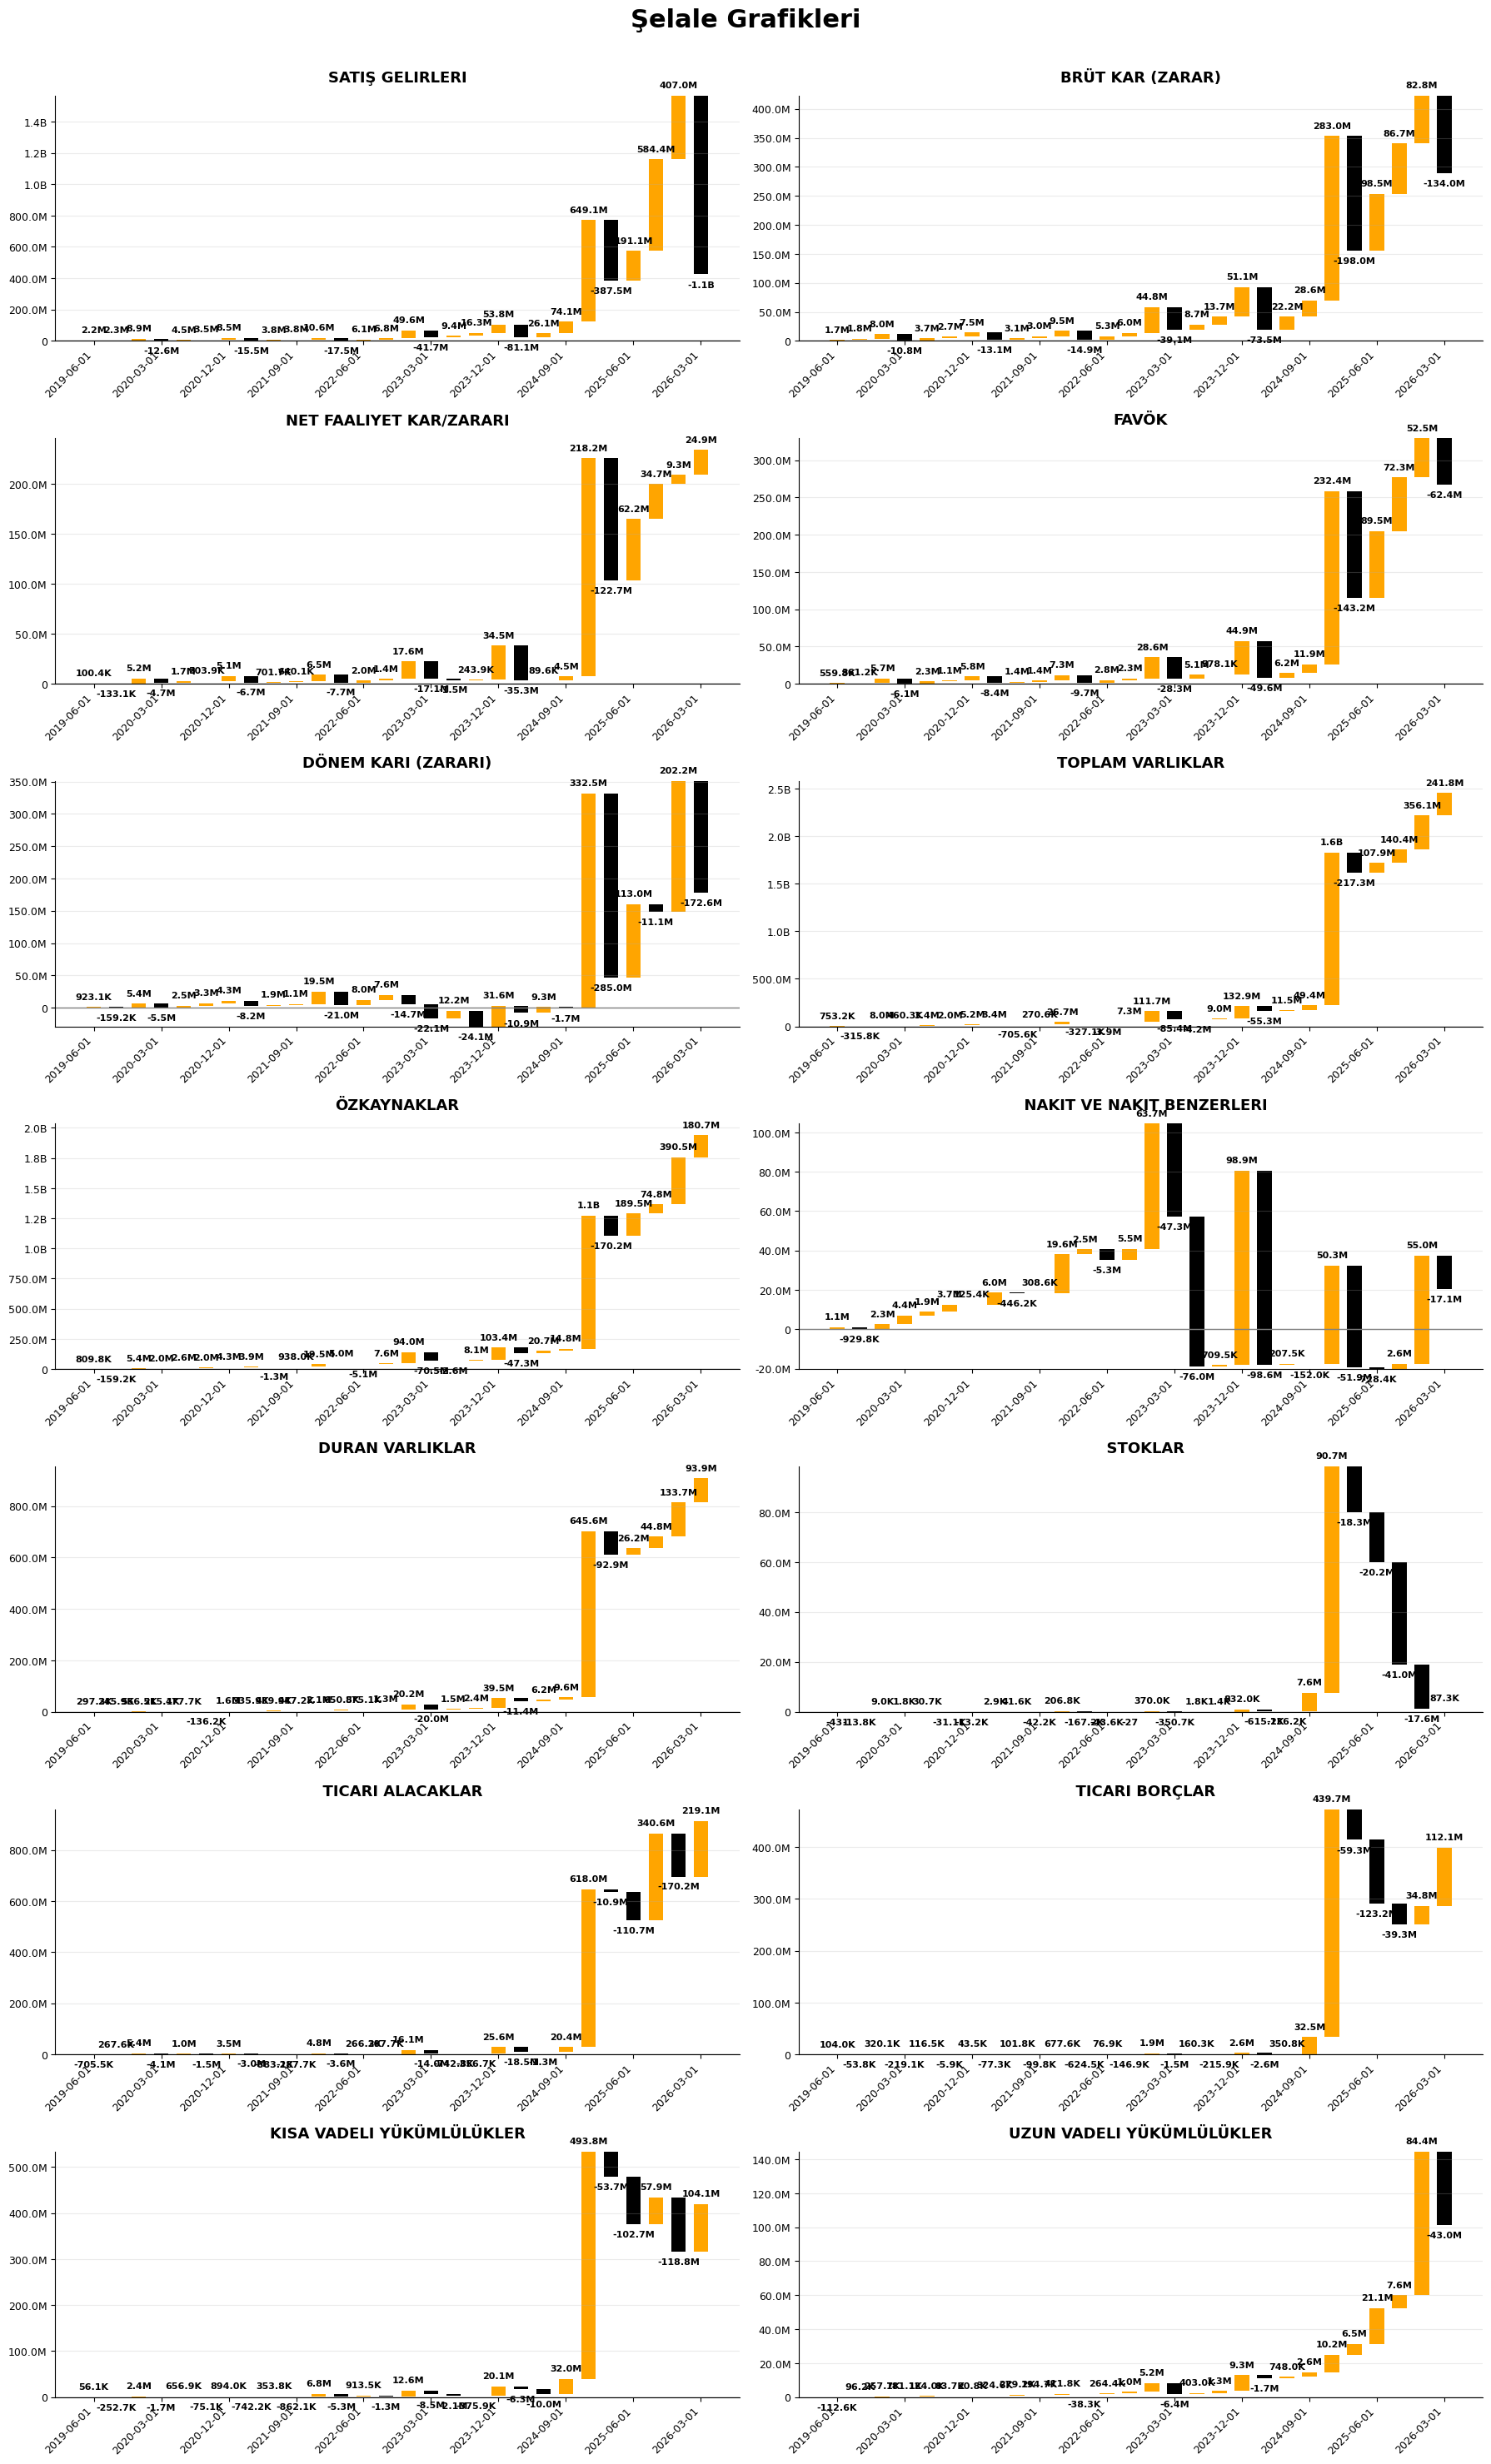

****************************************

Bilanço      Satış Gelirleri  BRÜT KAR (ZARAR)  Net Faaliyet Kar/Zararı  \
2019-06-01      2,177,872.00      1,650,240.00               100,444.00   
2019-09-01      2,344,403.00      1,828,500.00              -133,104.00   
2019-12-01      8,876,425.00      8,048,157.00             5,166,187.00   
2020-03-01    -12,556,233.00    -10,804,023.00            -4,739,838.00   
2020-06-01      4,514,640.00      3,741,201.00             1,703,172.00   
2020-09-01      3,475,879.00      2,700,885.00               503,889.00   
2020-12-01      8,464,707.00      7,492,874.00             5,116,117.00   
2021-03-01    -15,485,548.00    -13,094,427.00            -6,687,102.00   
2021-06-01      3,782,203.00      3,074,953.00               701,710.00   
2021-09-01      3,773,706.00      3,026,986.00               640,122.00   
2021-12-01     10,640,163.00      9,543,492.00             6,502,808.00   
2022-03-01    -17,461,219.00    -14,904,418.00            

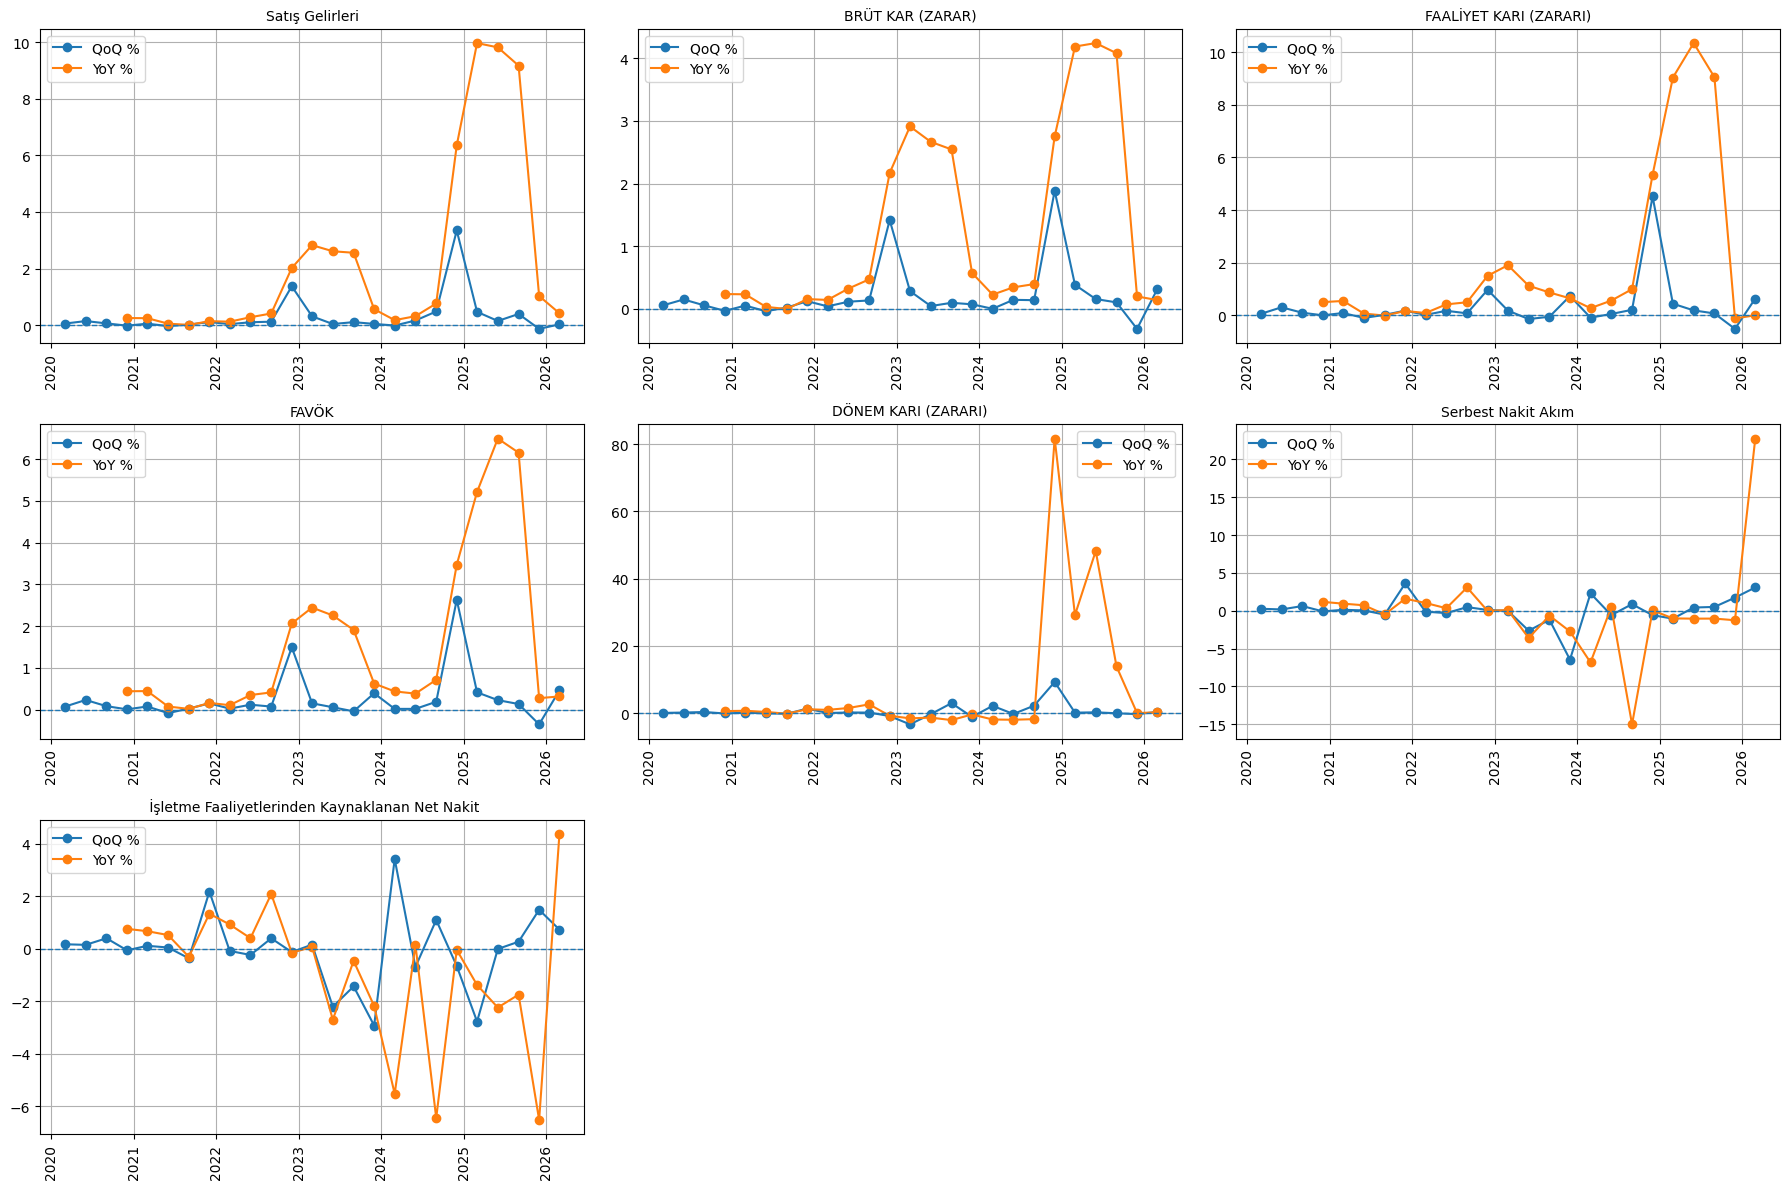

****************************************

            Satış Gelirleri_qoq_%  Satış Gelirleri_yoy_%  \
2019-12-01                    NaN                    NaN   
2020-03-01                   0.05                    NaN   
2020-06-01                   0.14                    NaN   
2020-09-01                   0.06                    NaN   
2020-12-01                  -0.02                   0.25   
2021-03-01                   0.05                   0.24   
2021-06-01                  -0.04                   0.05   
2021-09-01                   0.02                   0.01   
2021-12-01                   0.11                   0.14   
2022-03-01                   0.03                   0.12   
2022-06-01                   0.10                   0.28   
2022-09-01                   0.12                   0.41   
2022-12-01                   1.37                   2.02   
2023-03-01                   0.31                   2.83   
2023-06-01                   0.04                   2.61  

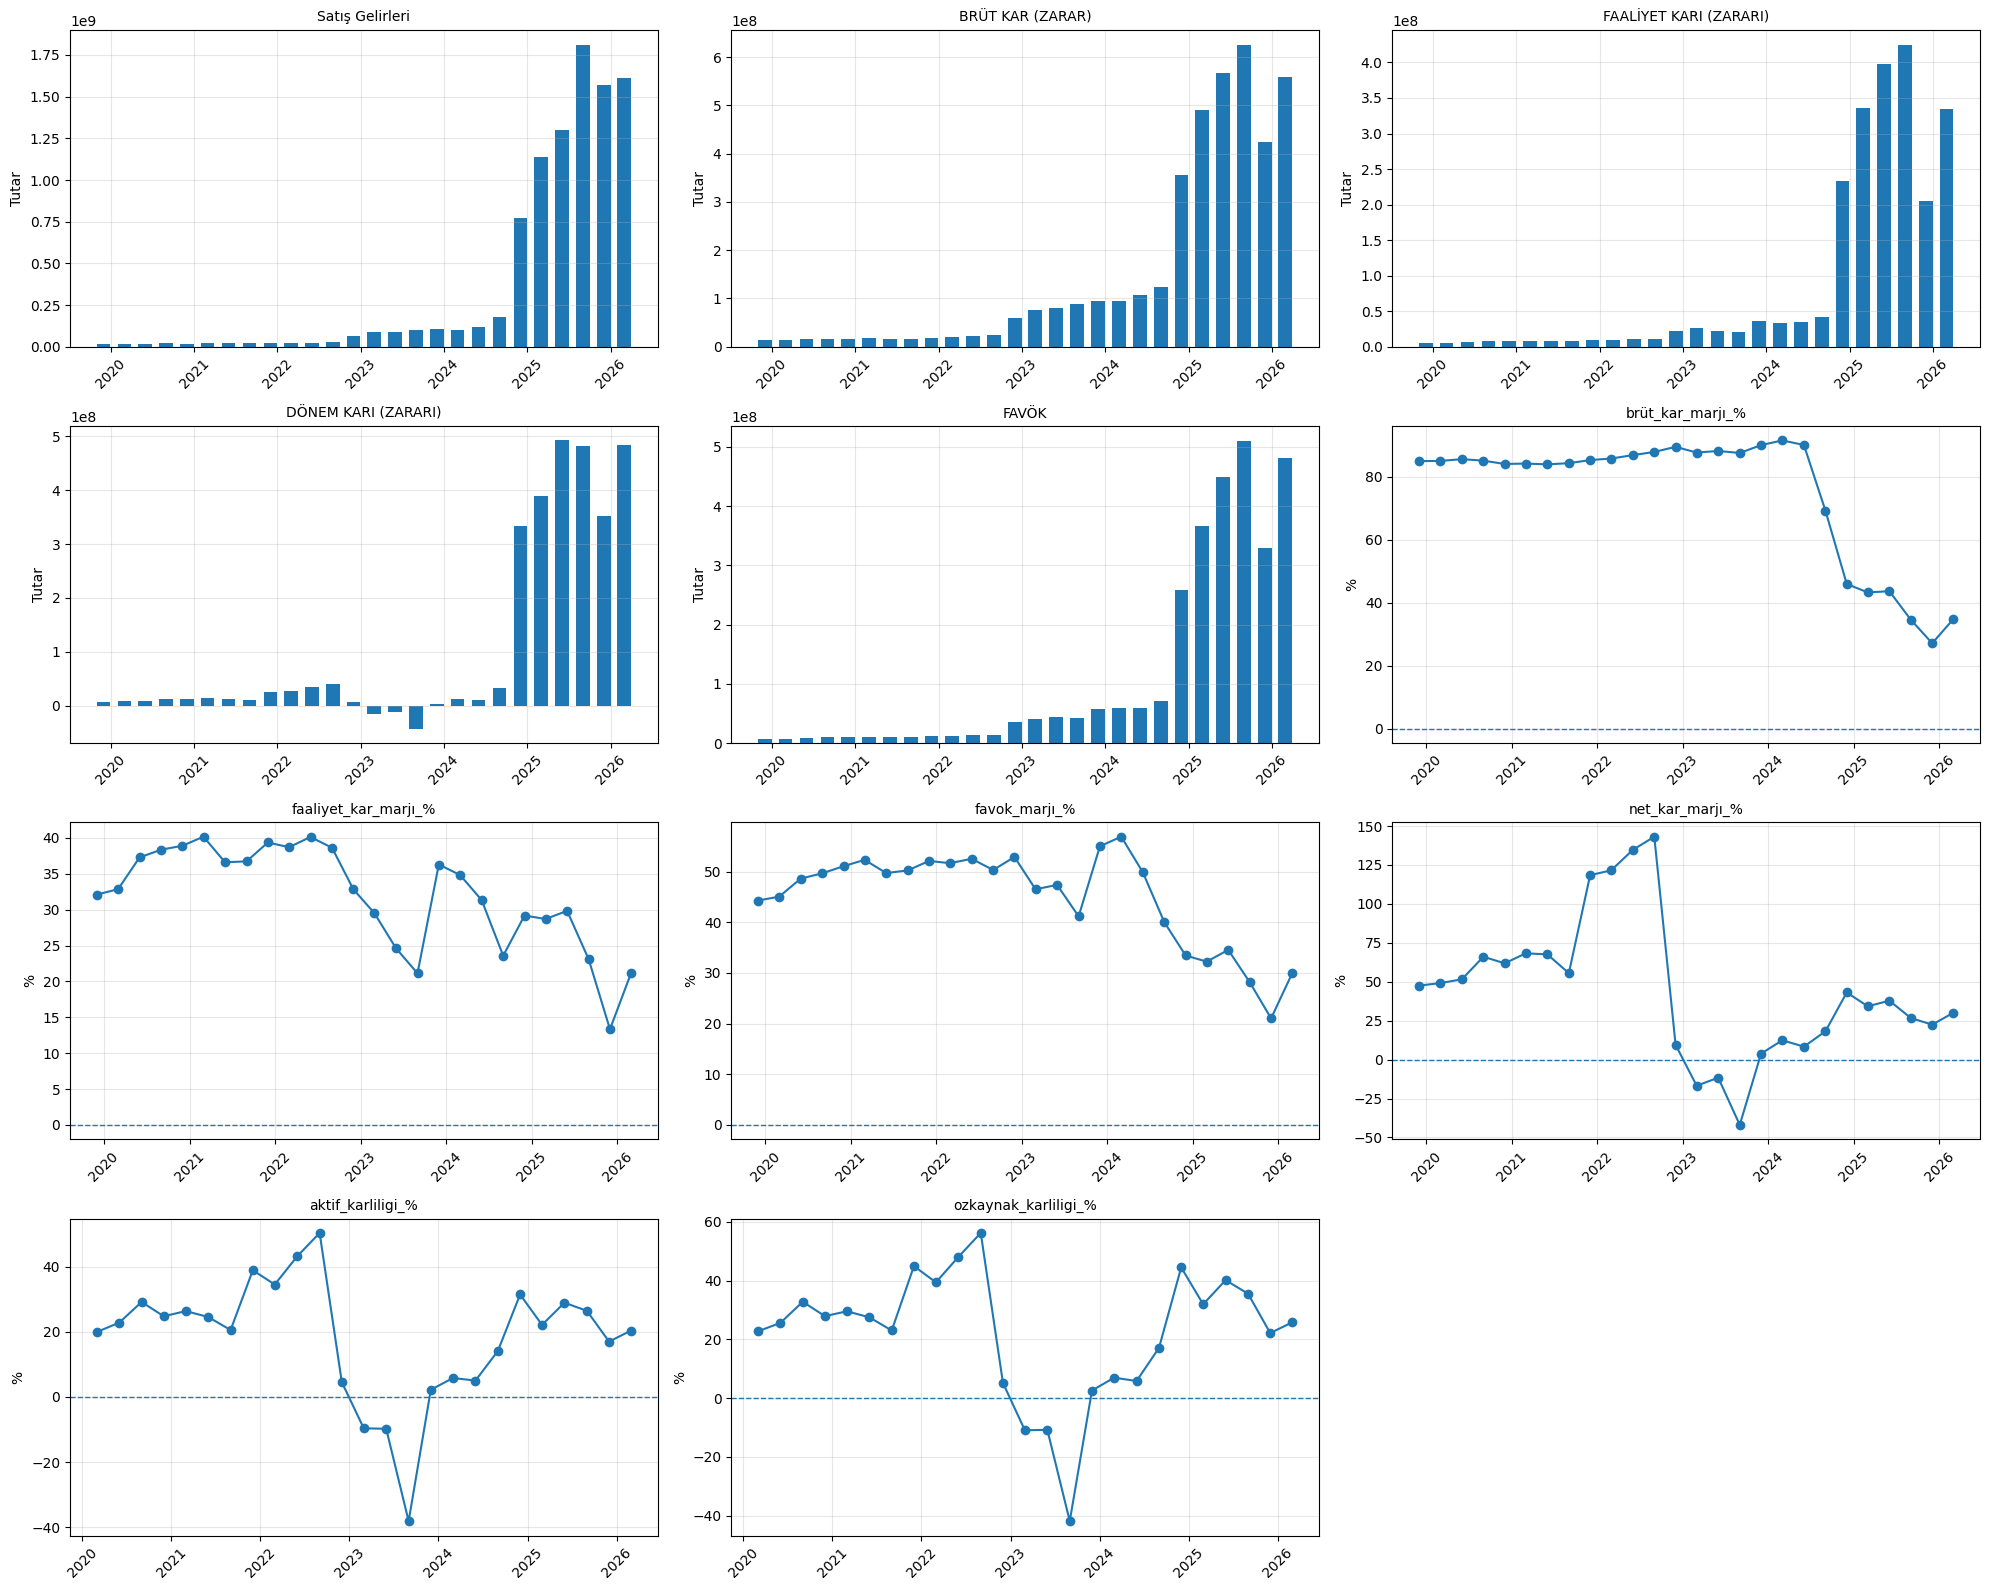

****************************************

            Satış Gelirleri  BRÜT KAR (ZARAR)  FAALİYET KARI (ZARARI)  \
2019-12-01    15,672,440.00     13,306,262.00            5,134,113.00   
2020-03-01    16,514,907.00     14,029,136.00            5,407,561.00   
2020-06-01    18,851,675.00     16,120,097.00            7,042,420.00   
2020-09-01    19,983,151.00     16,992,482.00            7,714,317.00   
2020-12-01    19,571,433.00     16,437,199.00            7,697,641.00   
2021-03-01    20,541,111.00     17,277,732.00            8,346,878.00   
2021-06-01    19,808,674.00     16,611,484.00            7,491,993.00   
2021-09-01    20,106,501.00     16,937,585.00            7,608,083.00   
2021-12-01    22,281,957.00     18,988,203.00            8,942,170.00   
2022-03-01    23,016,810.00     19,729,216.00            9,058,429.00   
2022-06-01    25,312,367.00     21,966,413.00           10,591,004.00   
2022-09-01    28,356,250.00     24,897,930.00           11,364,229.00   
2022-12-0

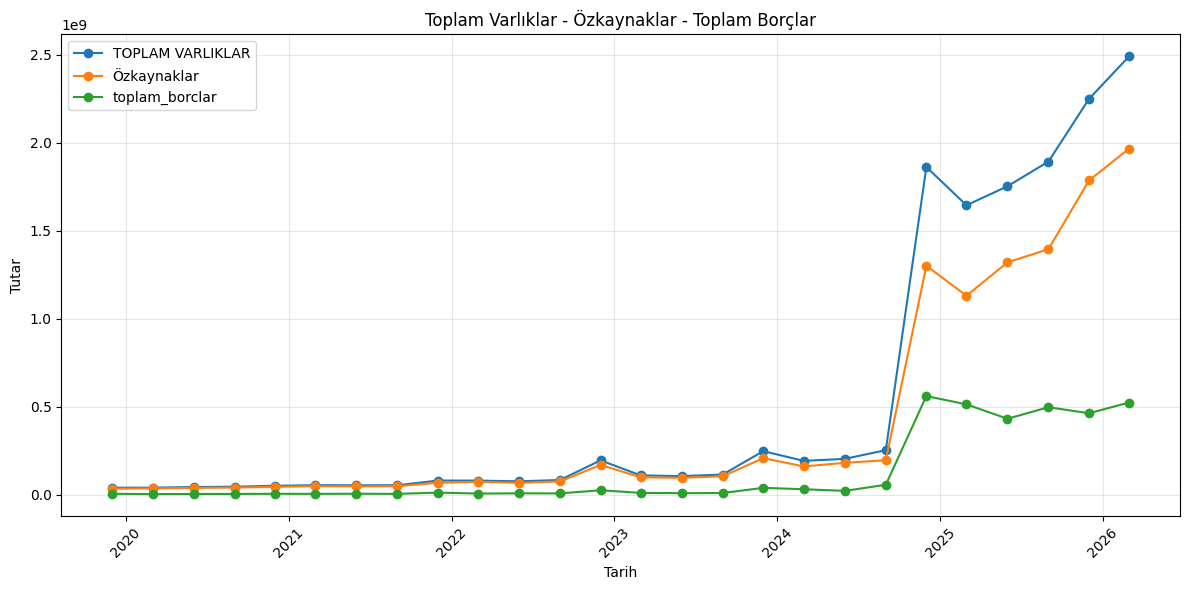

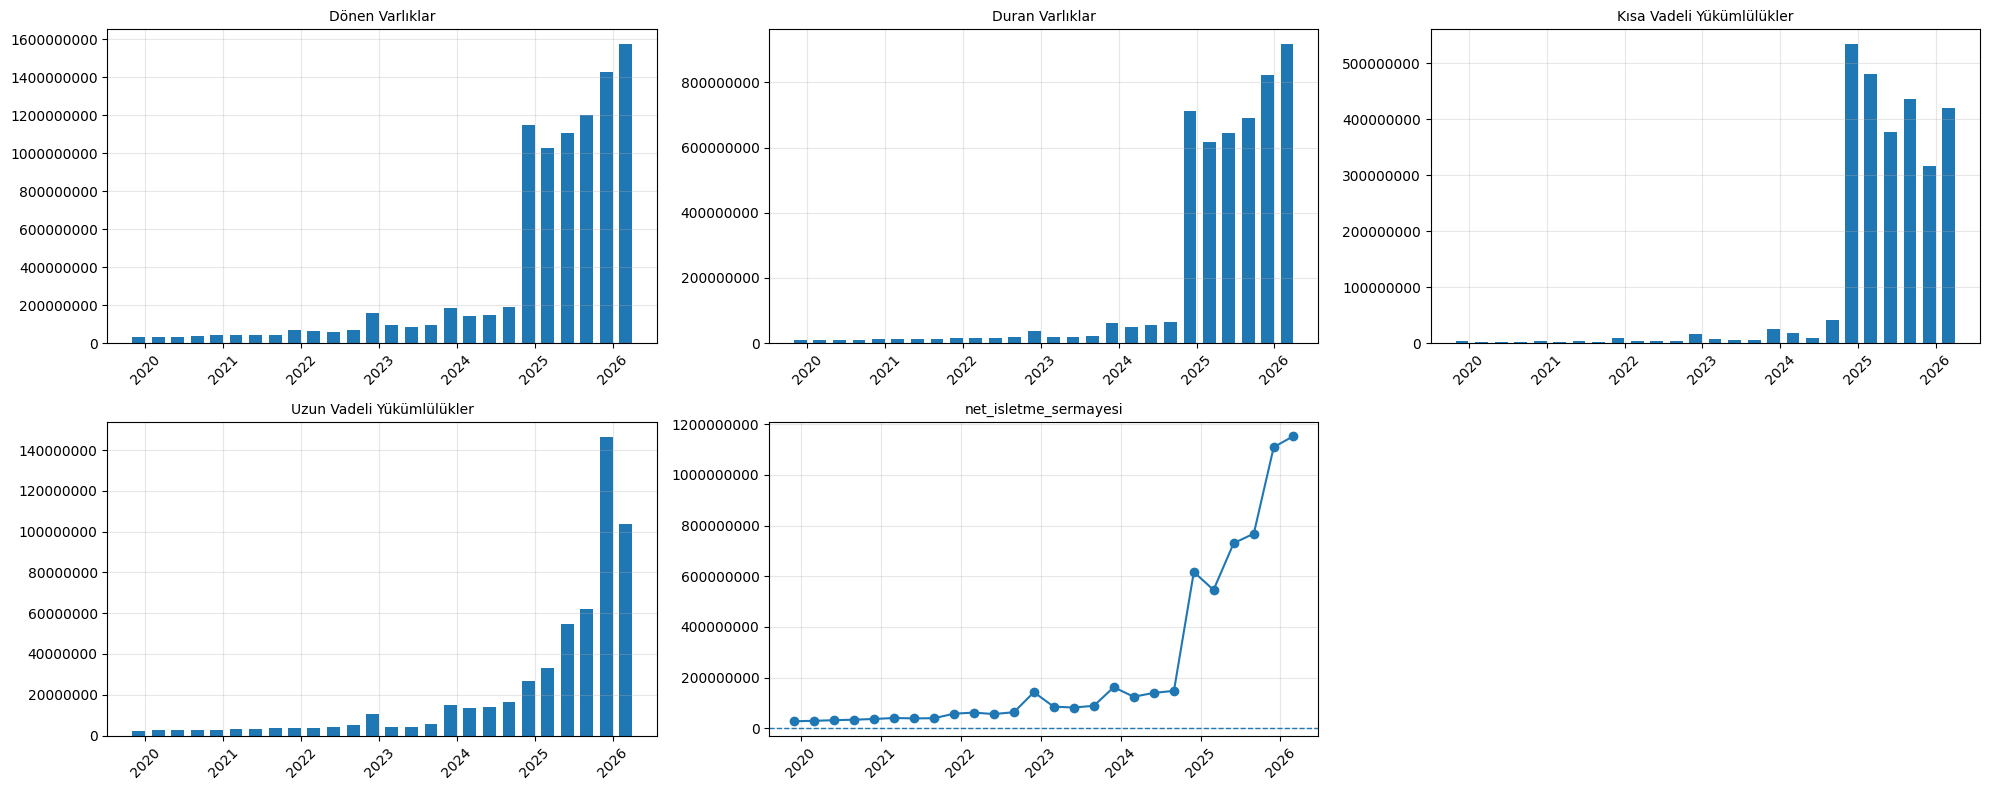

****************************************

            Dönen Varlıklar  Duran Varlıklar  TOPLAM VARLIKLAR  \
2019-12-01    31,091,224.00     9,330,768.00     40,421,992.00   
2020-03-01    31,336,417.00     9,545,846.00     40,882,263.00   
2020-06-01    34,221,364.00    10,023,498.00     44,244,862.00   
2020-09-01    36,332,659.00     9,887,316.00     46,219,975.00   
2020-12-01    39,953,728.00    11,439,154.00     51,392,882.00   
2021-03-01    43,056,243.00    11,775,009.00     54,831,252.00   
2021-06-01    41,910,737.00    12,214,923.00     54,125,660.00   
2021-09-01    41,734,118.00    12,662,141.00     54,396,259.00   
2021-12-01    66,311,942.00    14,805,149.00     81,117,091.00   
2022-03-01    65,334,356.00    15,455,601.00     80,789,957.00   
2022-06-01    60,545,035.00    16,330,743.00     76,875,778.00   
2022-09-01    66,489,724.00    17,667,216.00     84,156,940.00   
2022-12-01   158,027,750.00    37,855,240.00    195,882,990.00   
2023-03-01    92,603,658.00    17,

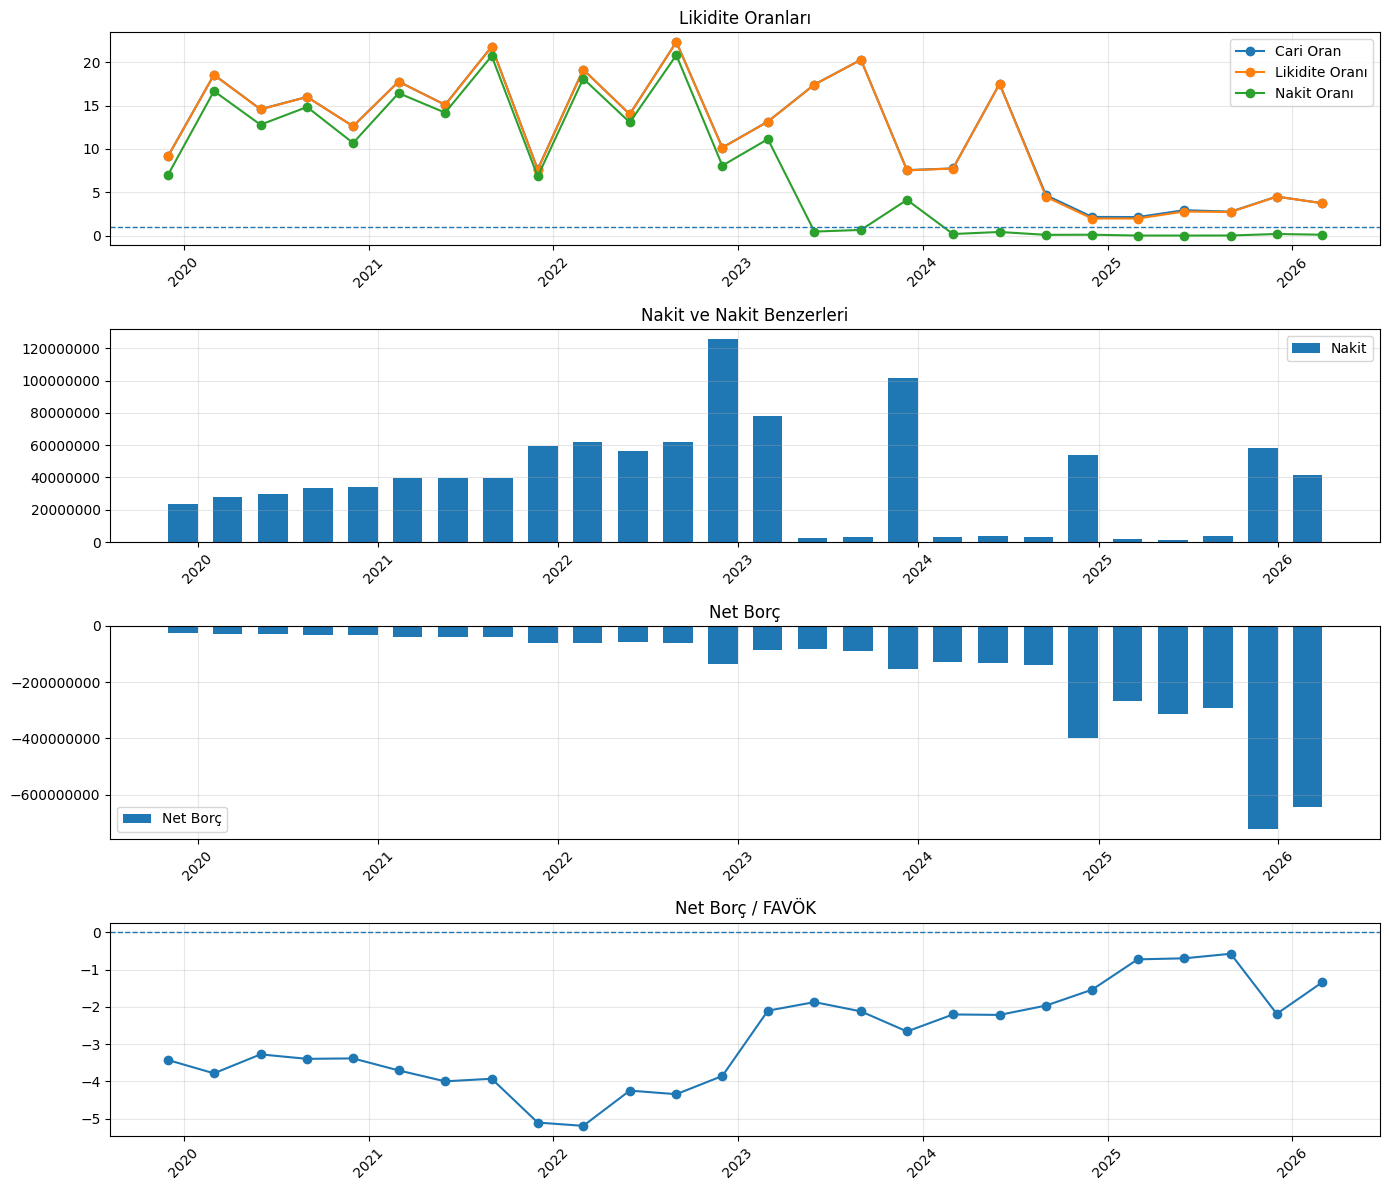


NAKİT DÖNGÜSÜ


 FAALİYET VERİMLİLİĞİ / YETERLİLİK ANALİZİ (SON DÖNEM)

aktif_devir_hizi: 0.76 → 0.68 | Azalış: 0.08 (%10.32)
alacak_devir_hizi: 2.00 → 1.99 | Azalış: 0.01 (%0.49)
stok_devir_hizi: 113.06 → 788.38 | Artış: 675.31 (%597.28)
borc_devir_hizi: 4.25 → 3.07 | Azalış: 1.18 (%27.85)
alacak_tahsil_suresi_gun: 182.19 → 183.08 | Artış: 0.89 (%0.49)
stok_gun_sayisi: 3.23 → 0.46 | Azalış: 2.77 (%85.66)
borc_odeme_suresi: 85.82 → 118.94 | Artış: 33.12 (%38.60)
nakit_dongu: 99.60 → 64.60 | Azalış: 35.00 (%35.14)


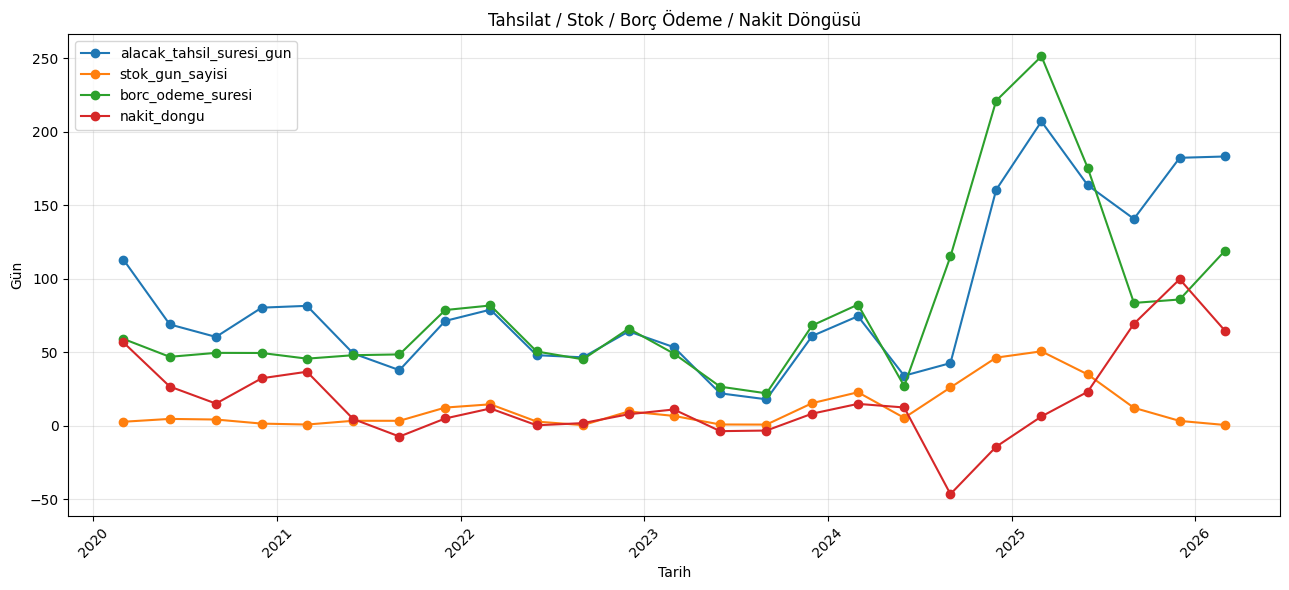

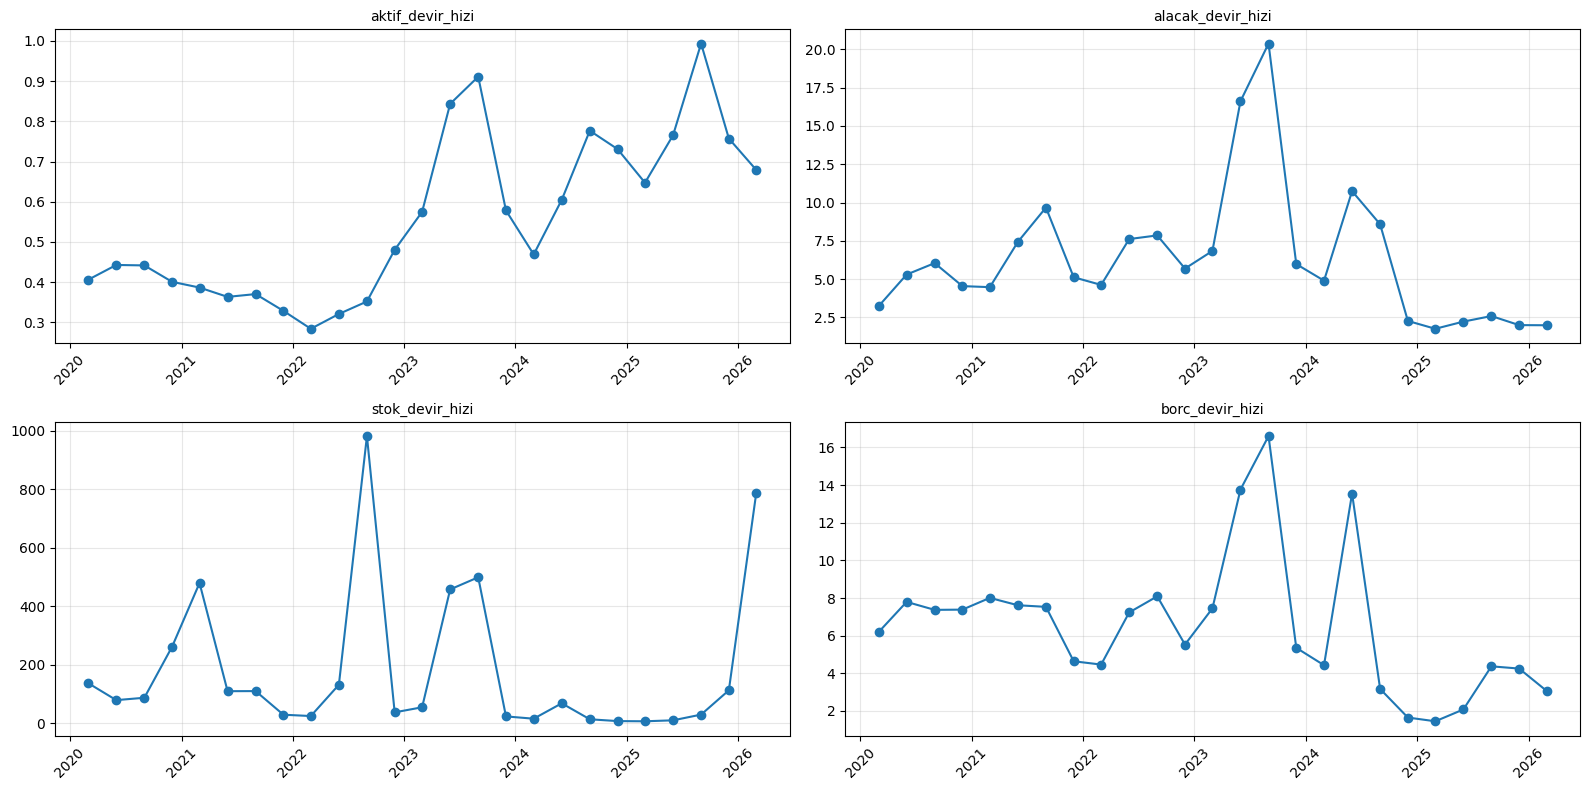

****************************************

            aktif_devir_hizi  alacak_devir_hizi  stok_devir_hizi  \
2019-12-01               NaN                NaN              NaN   
2020-03-01              0.41               3.23           137.38   
2020-06-01              0.44               5.30            79.50   
2020-09-01              0.44               6.05            87.60   
2020-12-01              0.40               4.55           262.03   
2021-03-01              0.39               4.48           479.70   
2021-06-01              0.36               7.43           110.06   
2021-09-01              0.37               9.67           110.36   
2021-12-01              0.33               5.12            29.68   
2022-03-01              0.28               4.63            25.14   
2022-06-01              0.32               7.62           132.06   
2022-09-01              0.35               7.85           981.78   
2022-12-01              0.48               5.69            37.76   
2023-0

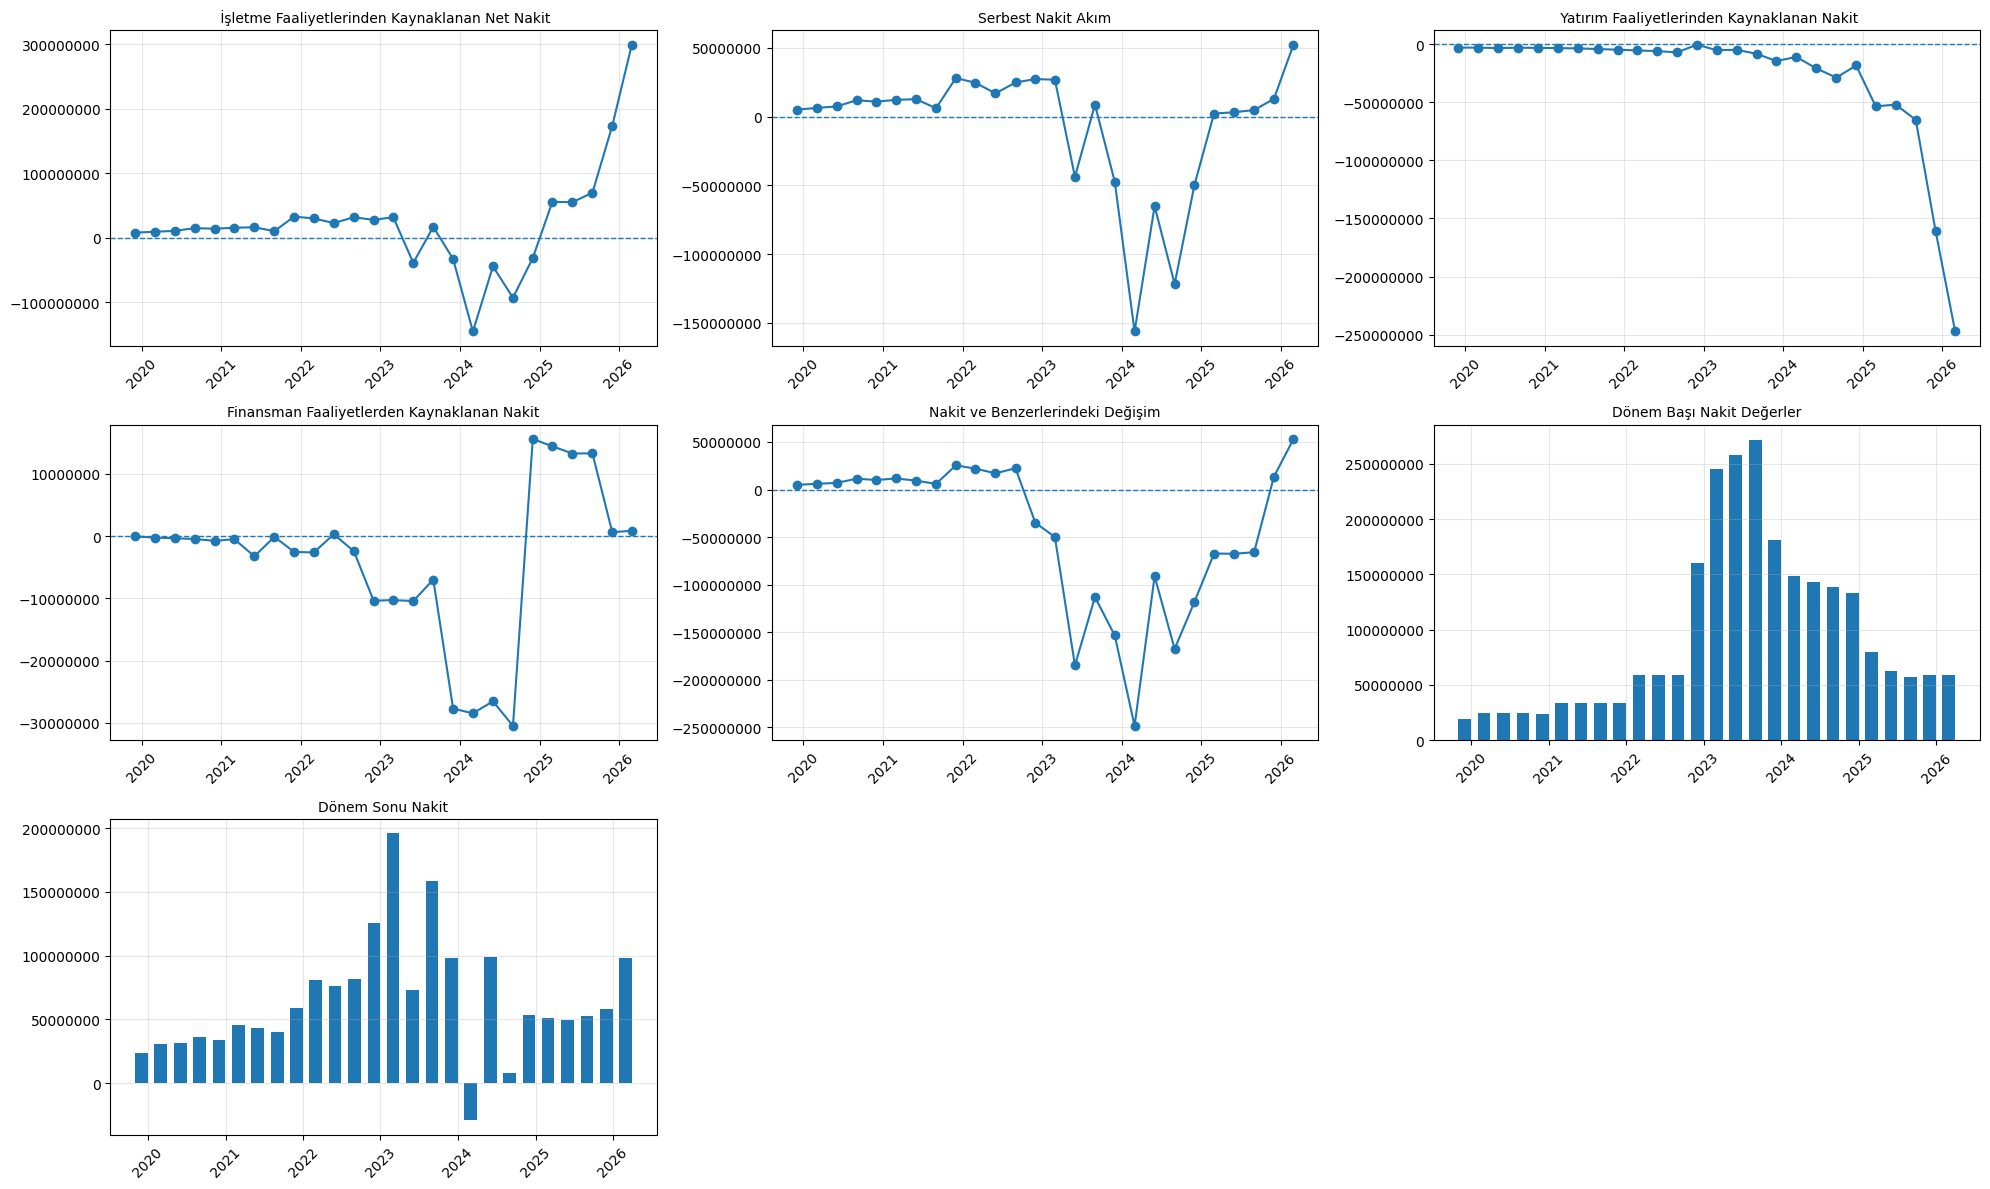

****************************************

             İşletme Faaliyetlerinden Kaynaklanan Net Nakit  \
2019-12-01                                     8,014,988.00   
2020-03-01                                     9,366,870.00   
2020-06-01                                    10,740,746.00   
2020-09-01                                    15,005,055.00   
2020-12-01                                    14,071,288.00   
2021-03-01                                    15,618,284.00   
2021-06-01                                    16,322,134.00   
2021-09-01                                    10,333,087.00   
2021-12-01                                    32,840,277.00   
2022-03-01                                    30,032,872.00   
2022-06-01                                    22,844,304.00   
2022-09-01                                    31,890,798.00   
2022-12-01                                    27,751,434.00   
2023-03-01                                    32,051,466.00   
2023-06-01   

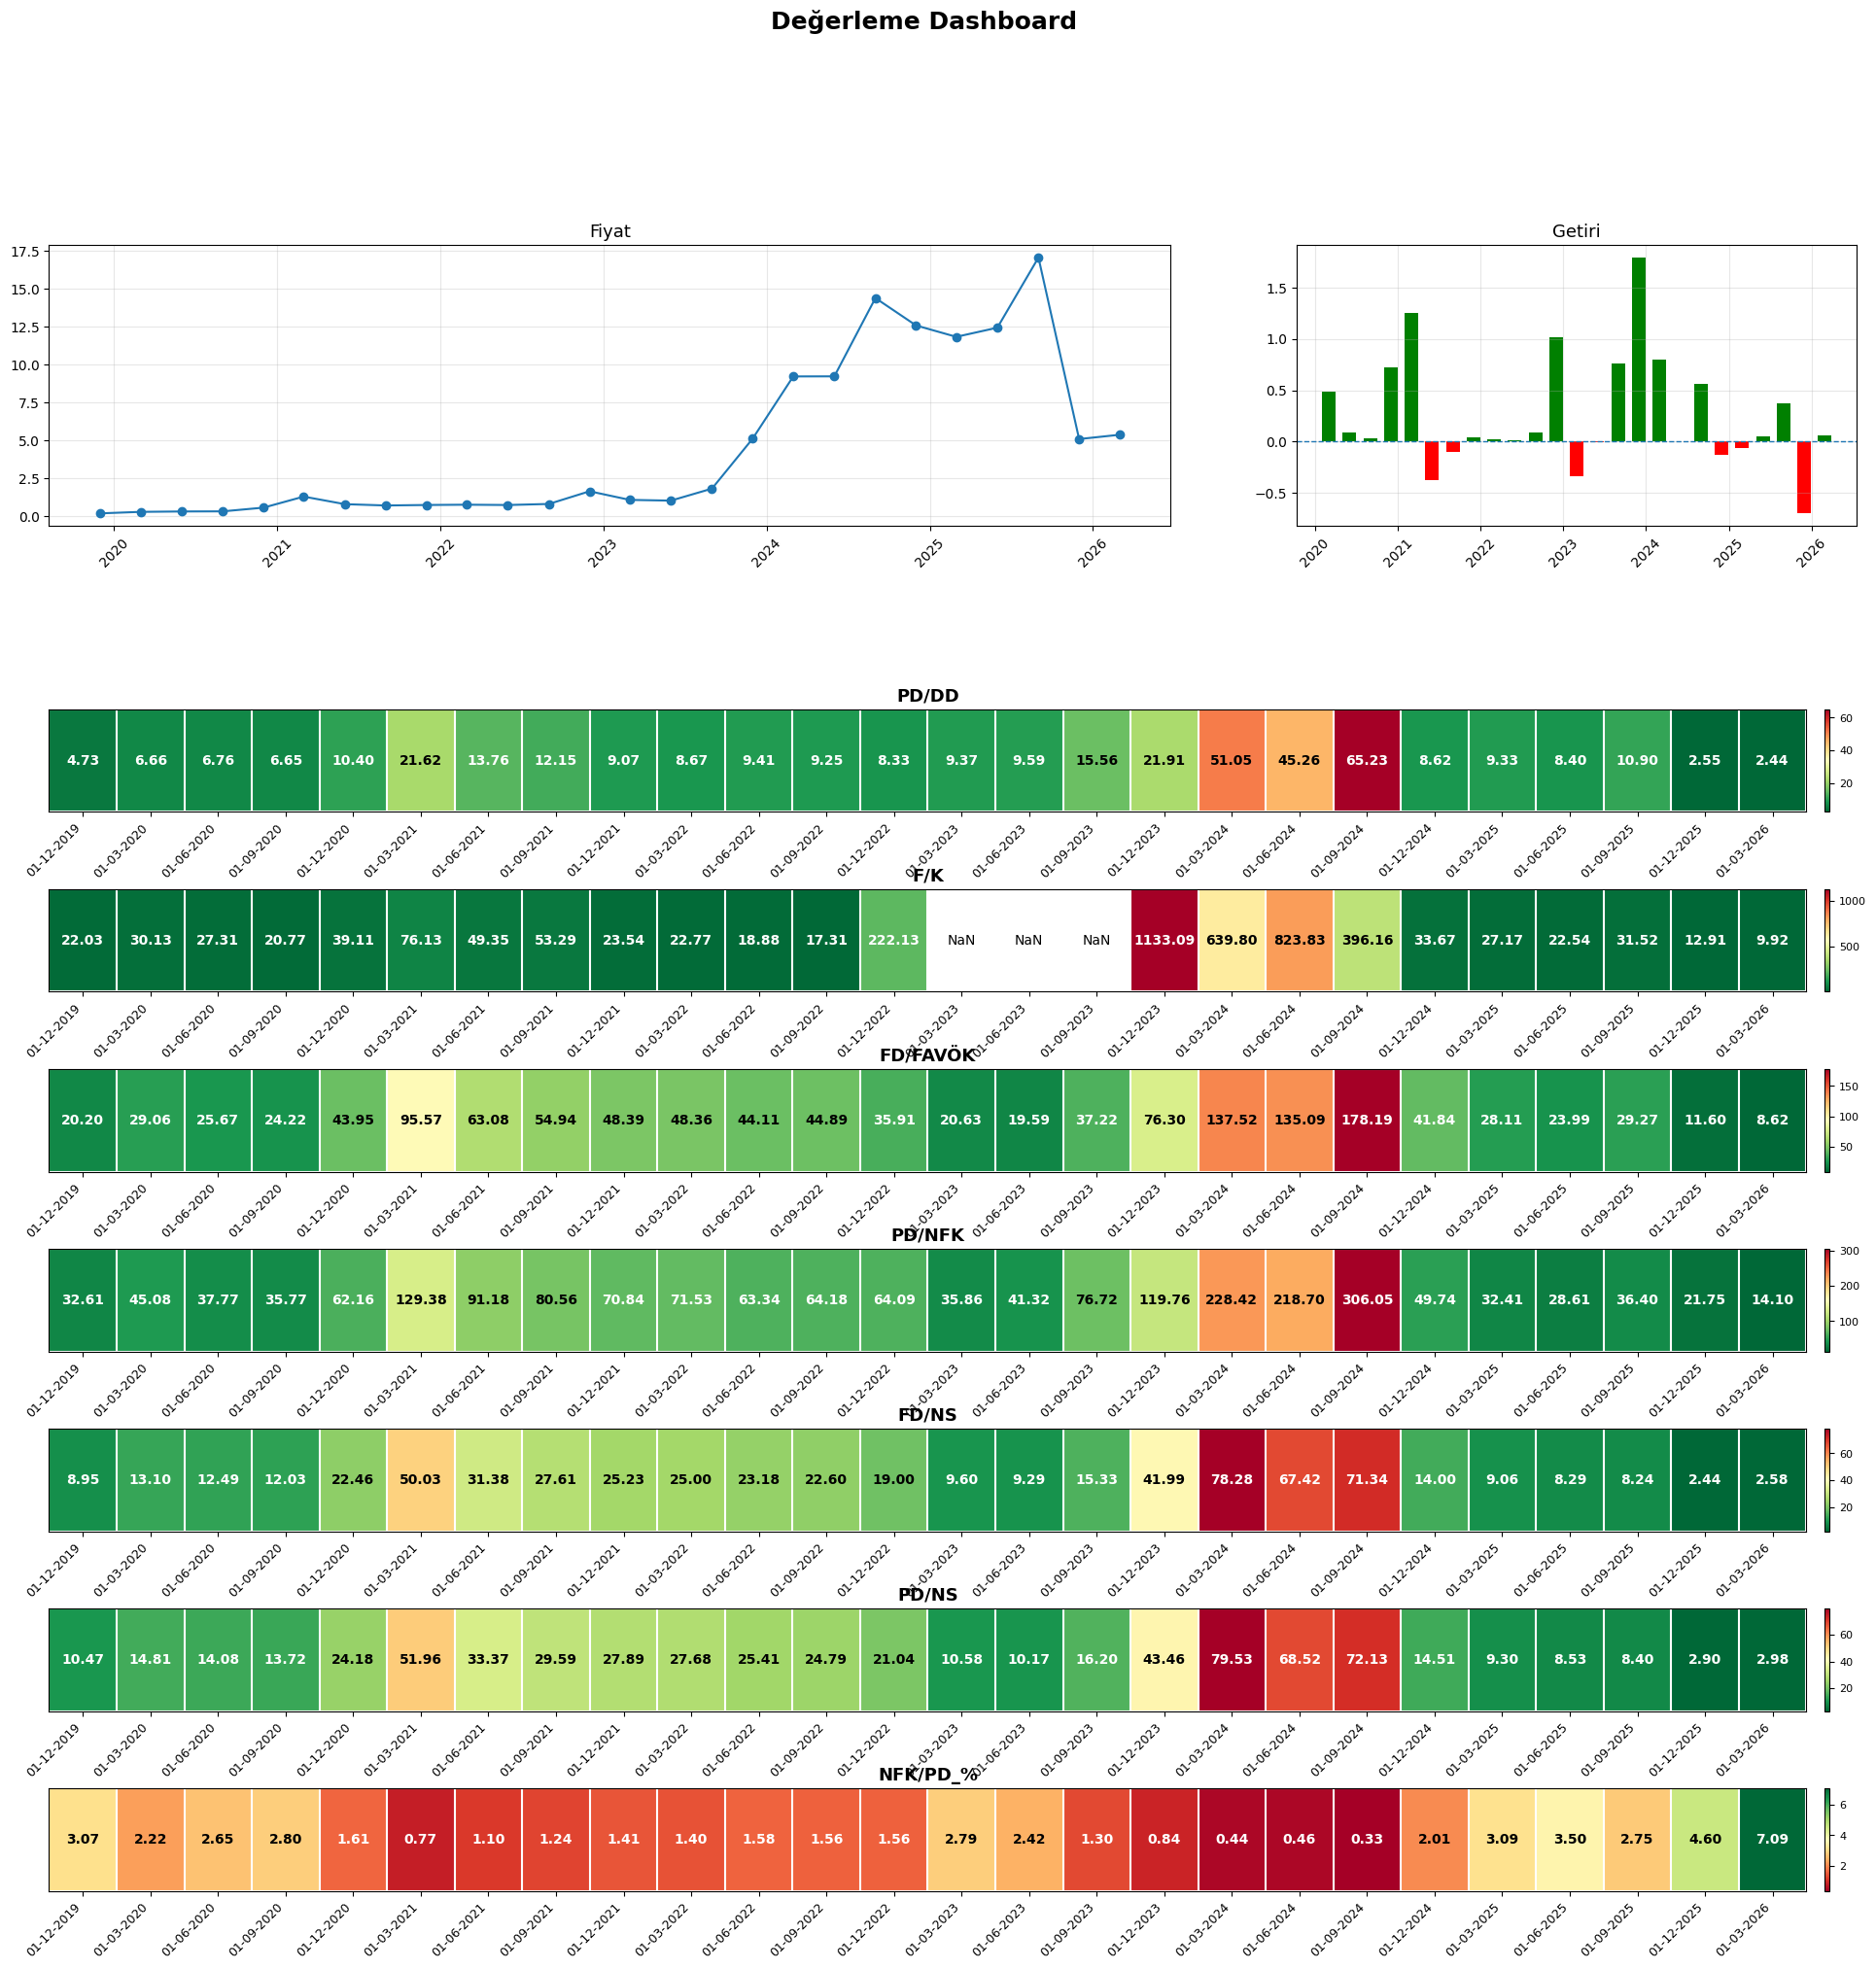


 DEĞERLEME ANALİZİ (SON DÖNEM)

fiyat: 5.10 → 5.38 | Değişim: 0.28 | %5.49 | artmış
getiri: -0.70 → 0.05 | Değişim: 0.76 | %107.83 | artmış
PD/DD: 2.55 → 2.44 | Değişim: -0.11 | %-4.20 | azalmış
F/K: 12.91 → 9.92 | Değişim: -2.99 | %-23.17 | azalmış
FD/FAVÖK: 11.60 → 8.62 | Değişim: -2.98 | %-25.71 | azalmış
PD/NFK: 21.75 → 14.10 | Değişim: -7.65 | %-35.17 | azalmış
FD/NS: 2.44 → 2.58 | Değişim: 0.14 | %5.73 | artmış
PD/NS: 2.90 → 2.98 | Değişim: 0.08 | %2.79 | artmış
NFK/PD_%: 4.60 → 7.09 | Değişim: 2.49 | %54.24 | artmış
****************************************

            fiyat  getiri                PD                FD  PD/DD      F/K  \
2019-12-01   0.20     NaN    164,068,095.90    140,282,989.90   4.73    22.03   
2020-03-01   0.30    0.49    244,525,553.93    216,371,480.93   6.66    30.13   
2020-06-01   0.33    0.09    265,428,027.36    235,410,207.36   6.76    27.31   
2020-09-01   0.34    0.03    274,162,935.61    240,469,968.61   6.65    20.77   
2020-12-01   0.58    0.

In [2]:


def forecast_model_secici(*args, **kwargs):
    """Merkezi tahmin motorunu notebook/web gösterim kancasına bağlar."""
    kwargs.setdefault("show_func", show)
    return _forecast_model_secici_core(*args, **kwargs)


# -------------------------
# KULLANILAN FONKSİYONLAR
# -------------------------


# -------------------------
# 1 - Gelir tablosu dataframe oluşturma
# -------------------------

def gelir_tablosu(df, ceyrek=False, yillik=False):
    gelir_tab = df.loc[:, df.columns[df.columns.tolist().index("Satış Gelirleri"):]].copy()
    gelir_tab["dönem"] = gelir_tab.index.month
    gelir_tab["yil"] = gelir_tab.index.year
    if ceyrek:
        cols = gelir_tab.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        gelir_tab_cey = gelir_tab.copy()
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        return gelir_tab_cey
    elif yillik:
        gelir_tab_cey = gelir_tab.copy()
        cols = gelir_tab_cey.select_dtypes(include="number").columns.drop(["dönem", "yil"])
        mask = gelir_tab_cey["dönem"] != 3
        gelir_tab_cey.loc[mask, cols] = (gelir_tab_cey.groupby("yil")[cols].diff())
        gelir_tab_yil =gelir_tab_cey.copy()
        gelir_tab_yil[cols] = gelir_tab_cey[cols].rolling(window=4).sum()
        gelir_tab_yil.dropna(inplace=True)
        return gelir_tab_yil
    else:
        return gelir_tab

# -------------------------
# 2 - Gelir tablosu kısmına yıllıklandırma uygulama ve bilanço ile birleştirme
# -------------------------
def bilanco_yillik(df, gelir_tab_yil):
    bilanco = df[df.columns.tolist()[:df.columns.tolist().index("Satış Gelirleri")]]
    bilanco = bilanco.loc[gelir_tab_yil.index,:]
    bilanco = bilanco.loc[:, ~bilanco.columns.duplicated()]
    new_df = bilanco.merge(gelir_tab_yil, how="inner", left_index=True, right_index=True)
    new_df["uzun_vadeli_finansal_borc"] = select_column_occurrence(
        df, "  Finansal Borçlar", occurrence=1, default=0.0
    ).reindex(new_df.index)
    new_df["uzun_vadeli_diger_finansal_yukumluluk"] = select_column_occurrence(
        df, "  Diğer Finansal Yükümlülükler", occurrence=1, default=0.0
    ).reindex(new_df.index)
    return new_df

# -------------------------
# 3 - Oran ve rasyoların hesaplanması
# -------------------------
def guvenli_yuzde_degisim(series, periods):
    """Yüzde değişim hesaplar; işaret değişimi (negatiften pozitife/pozitiften
    negatife geçiş) veya sıfırdan geçiş olduğunda sonucu NaN yapar. Standart
    yüzde değişim formülü (curr-prev)/prev, taban değerin işareti değiştiğinde
    yanıltıcı sonuçlar üretir (örn. -100 → 50 için %-150 gibi anlamsız bir
    "azalış" görünür); bu durumlarda NaN döndürmek grafiksel yorumu netleştirir.
    """
    prev = series.shift(periods)
    change = series.pct_change(periods, fill_method=None)
    ayni_yon = ((prev > 0) & (series > 0)) | ((prev < 0) & (series < 0))
    return change.where(ayni_yon)


def oran_rasyo_hesaplama(new_df, hisse, bilanco_df=None):
    # Ödenmiş sermaye geçmişini koru; bölünme olayları fiyat verisiyle
    # birlikte aşağıda aynı pay bazına getirilecektir.

    new_df["brüt_kar_marjı_%"] = (new_df["BRÜT KAR (ZARAR)"]/new_df["Satış Gelirleri"]) * 100
    new_df["faaliyet_kar_marjı_%"] = (new_df["Net Faaliyet Kar/Zararı"]/new_df["Satış Gelirleri"])*100
    new_df["favok_marjı_%"] = (new_df["FAVÖK"]/new_df["Satış Gelirleri"])*100
    new_df["net_kar_marjı_%"] = (new_df["Ana Ortaklık Payları"]/new_df["Satış Gelirleri"])*100
    
    new_df["ortalama_toplam_aktifler"] = (
        new_df["TOPLAM VARLIKLAR"] + new_df["TOPLAM VARLIKLAR"].shift(1)
    ) / 2
    
    new_df["aktif_karliligi_%"] = (new_df["Ana Ortaklık Payları"] / new_df["ortalama_toplam_aktifler"])*100
    
    new_df["ortalama_toplam_ozkaynak"] = (
        new_df["  Ana Ortaklığa Ait Özkaynaklar"] + new_df["  Ana Ortaklığa Ait Özkaynaklar"].shift(1)
    ) / 2
    
    new_df["ozkaynak_karliligi_%"] = (new_df["Ana Ortaklık Payları"] / new_df["ortalama_toplam_ozkaynak"])*100
    
    new_df["toplam_borclar"] = new_df["Kısa Vadeli Yükümlülükler"] + new_df["Uzun Vadeli Yükümlülükler"]
    new_df["ozkaynak_borclulugu_%"] = (new_df["toplam_borclar"] / new_df["  Ana Ortaklığa Ait Özkaynaklar"])*100
    
    new_df["aktif_borclulugu_%"] = (new_df["toplam_borclar"] / new_df["TOPLAM VARLIKLAR"]) *100
    
    new_df = calculate_coverage_and_export_ratios(new_df)
    
    new_df["aktif_devir_hizi"] = new_df["Satış Gelirleri"] / new_df["ortalama_toplam_aktifler"]
    
    new_df["ortalama_ticari_alacak"] = (
        new_df["  Ticari Alacaklar"] + new_df["  Ticari Alacaklar"].shift(1)
    ) / 2
    
    new_df["alacak_devir_hizi"] = new_df["Satış Gelirleri"] / new_df["ortalama_ticari_alacak"]
    
    new_df["ortalama_stok"] = (
        new_df["  Stoklar"] + new_df["  Stoklar"].shift(1)
    ) / 2
    
    new_df["stok_devir_hizi"] = new_df["Satışların Maliyeti (-)"].abs() / new_df["ortalama_stok"]
    
    new_df["ortalama_ticari_borc"] = (
        new_df["  Ticari Borçlar"] + new_df["  Ticari Borçlar"].shift(1)
    ) / 2
    
    new_df["borc_devir_hizi"] = new_df["Satışların Maliyeti (-)"].abs() / new_df["ortalama_ticari_borc"]
    
    new_df["alacak_tahsil_suresi_gun"] = 365 / new_df["alacak_devir_hizi"]
    
    new_df["stok_gun_sayisi"] = 365 / new_df["stok_devir_hizi"]
    
    new_df["borc_odeme_suresi"] = 365 / new_df["borc_devir_hizi"]
    
    new_df["nakit_dongu"] = (new_df["alacak_tahsil_suresi_gun"] + new_df["stok_gun_sayisi"]) - new_df["borc_odeme_suresi"]
    
    new_df["net_isletme_sermayesi"] = new_df["Dönen Varlıklar"] - new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["cari_oran"] = new_df["Dönen Varlıklar"] / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["likitide_oranı"] = (new_df["Dönen Varlıklar"] - new_df["  Stoklar"]) / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["nakit_oranı"] = new_df["  Nakit ve Nakit Benzerleri"] / new_df["Kısa Vadeli Yükümlülükler"]
    
    new_df["net_borc"] = (
        new_df["  Finansal Borçlar"]
        + new_df["  Diğer Finansal Yükümlülükler"]
        + new_df["uzun_vadeli_finansal_borc"]
        + new_df["uzun_vadeli_diger_finansal_yukumluluk"]
        - new_df["  Nakit ve Nakit Benzerleri"]
        - new_df["  Finansal Yatırımlar"]
    )
    
    new_df["net_borc/FAVOK"] = new_df["net_borc"] / new_df["FAVÖK"]

    new_df = new_df.copy()
    new_df.index = pd.to_datetime(new_df.index)
    new_df = new_df.sort_index()
    sirket = hisse + ".IS"
    
    prices_raw = yf_download_safe(
        sirket,
        start=new_df.index.min() - pd.Timedelta(days=10),
        end=pd.Timestamp.today().normalize() + pd.Timedelta(days=1),
        auto_adjust=False,
        actions=True,
        progress=False,
        multi_level_index=False
    )
    
    split_events = (
        prices_raw["Stock Splits"]
        if "Stock Splits" in prices_raw.columns
        else pd.Series(dtype=float)
    )
    new_df["  Ödenmiş Sermaye"], new_df["sermaye_duzeltme_katsayisi"] = (
        split_adjusted_paid_capital(new_df["  Ödenmiş Sermaye"], split_events)
    )
    new_df["hbk"] = (
        new_df["Ana Ortaklık Payları"] / new_df["  Ödenmiş Sermaye"]
    )
    prices = prepare_split_consistent_prices(prices_raw)
    
    new_df.index = new_df.index.astype("datetime64[s]")
    prices.index = prices.index.astype("datetime64[s]")
    
    df = pd.merge_asof(
        new_df.sort_index(),
        prices.sort_index(),
        left_index=True,
        right_index=True,
        direction="backward"
    )
    
    # Aynı fiyat serisinin son satırı güncel işlem fiyatını da içerir;
    # ikinci bir yfinance çağrısına gerek yoktur.
    if not prices.empty:
        guncel_fiyat = prices["fiyat"].iloc[-1]
        guncel_duzeltilmis_fiyat = prices["duzeltilmis_fiyat"].iloc[-1]
        guncel_toplam_getiri_fiyati = prices["toplam_getiri_fiyati"].iloc[-1]

        df.loc[df.index[-1], "fiyat"] = guncel_fiyat
        df.loc[df.index[-1], "duzeltilmis_fiyat"] = guncel_duzeltilmis_fiyat
        df.loc[df.index[-1], "toplam_getiri_fiyati"] = guncel_toplam_getiri_fiyati
    
    df["getiri"] = df["toplam_getiri_fiyati"].pct_change(fill_method=None)

    df["PD"] = df["  Ödenmiş Sermaye"] * df["duzeltilmis_fiyat"]
    df["FD"] = df["PD"] + df["net_borc"]
    df["PD/DD"] = df["PD"] / df["  Ana Ortaklığa Ait Özkaynaklar"]
    df["F/K"] = df["duzeltilmis_fiyat"] / df["hbk"]
    df["FD/FAVÖK"] = df["FD"] / df["FAVÖK"]
    df["PD/NFK"] = df["PD"] / df["Net Faaliyet Kar/Zararı"]
    df["FD/NS"] = df["FD"] / df["Satış Gelirleri"]
    df["NFK/PD_%"] = (df["Net Faaliyet Kar/Zararı"] / df["PD"])*100
    df["PD/NS"] = df["PD"] / df["Satış Gelirleri"]

    # negatifleri NaN yap
    degerleme_cols = ["PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS"]
    df[degerleme_cols] = df[degerleme_cols].mask(df[degerleme_cols] < 0, np.nan)

    buyume_adayları = ["Satış Gelirleri", "BRÜT KAR (ZARAR)", "FAALİYET KARI (ZARARI)", "FAVÖK", "DÖNEM KARI (ZARARI)",
                       "TOPLAM VARLIKLAR", "Özkaynaklar", "  Nakit ve Nakit Benzerleri",
                       "Duran Varlıklar", "Dönen Varlıklar", "  Stoklar", "  Ticari Alacaklar",
                       "  Ticari Borçlar", "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler",
                       "Serbest Nakit Akım", " İşletme Faaliyetlerinden Kaynaklanan Net Nakit"]
    for col in buyume_adayları:
        df[f"{col}_qoq_%"] = guvenli_yuzde_degisim(df[col], 1)
        df[f"{col}_yoy_%"] = guvenli_yuzde_degisim(df[col], 4)

    return df

# -------------------------
# 4 - EVDS'den makro ekonomi verilerini alma
# -------------------------

def TUFE_alma(df, api_key):
    start_date = df.index[0]
    end_date = df.index[-1]

    start_date = start_date.strftime("%d-%m-%Y")
    end_date = end_date.strftime("%d-%m-%Y")

    evds = evdsAPI(api_key)
    makro_data = evds.get_data(['TP.FG.J0','TP.TUFE1YI.T1'],startdate=start_date,enddate=end_date, frequency = 5)
    makro_data.columns = ["Tarih", "TUFE", "UFE"]
    makro_data["log_TUFE"] = np.log1p(makro_data["TUFE"])
    makro_data["log_UFE"] = np.log1p(makro_data["UFE"])
    makro_data["tufe_yillik"] = makro_data["TUFE"].pct_change(12, fill_method=None)
    makro_data["ufe_yillik"] = makro_data["UFE"].pct_change(12, fill_method=None)
    makro_data["ufe_tufe_spread"] = makro_data["log_UFE"] - makro_data["log_TUFE"]
    makro_data.set_index("Tarih", inplace=True)
    makro_data.index = pd.to_datetime(makro_data.index, format="%Y-%m")
    return makro_data

# -------------------------
# 5 - EVDS'den makro ekonomi verilerini alma. TUFE tahmini yapılacaksa kullanılır. Başlangıç tarihi belirlidir.
# -------------------------
def TUFE_alma_2(df, api_key):
    start_date = "01-12-2019"
    end_date = df.index[-1]

    #start_date = start_date.strftime("%d-%m-%Y")
    end_date = end_date.strftime("%d-%m-%Y")

    evds = evdsAPI(api_key)
    makro_data = evds.get_data(['TP.FG.J0','TP.TUFE1YI.T1'],startdate=start_date,enddate=end_date, frequency = 5)
    makro_data.columns = ["Tarih", "TUFE", "UFE"]
    makro_data["log_TUFE"] = np.log1p(makro_data["TUFE"])
    makro_data["log_UFE"] = np.log1p(makro_data["UFE"])
    makro_data["tufe_yillik"] = makro_data["TUFE"].pct_change(12, fill_method=None)
    makro_data["ufe_yillik"] = makro_data["UFE"].pct_change(12, fill_method=None)
    makro_data["ufe_tufe_spread"] = makro_data["log_UFE"] - makro_data["log_TUFE"]
    makro_data.set_index("Tarih", inplace=True)
    makro_data.index = pd.to_datetime(makro_data.index, format="%Y-%m")
    return makro_data

# -------------------------
# 4 - Değişim yüzdelerinin zaman serisi grafikleri
# -------------------------

def degisim_plot(df):
    df2 = df.copy()
    
    qoq_cols = [col for col in df2.columns if "_qoq_" in col]
    yoy_cols = [col for col in df2.columns if "_yoy_" in col]

    metrics = [col.replace("_qoq_%", "") for col in qoq_cols]

    # subplot
    n = len(metrics)
    cols = 3
    rows = math.ceil(n / cols)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=metrics)

    print("\nDEĞİŞİM ANALİZİ (SON DÖNEM)\n")

    THRESHOLD = 0.02  # %2 altını yatay say

    for i, metric in enumerate(metrics):
        row, c = divmod(i, cols)

        qoq_col = metric + "_qoq_%"
        yoy_col = metric + "_yoy_%"

        show_legend = i == 0
        fig.add_trace(
            go.Scatter(x=df2.index, y=df2[qoq_col], mode="lines+markers", name="QoQ %",
                       legendgroup="qoq", showlegend=show_legend, line={"color": UP_COLOR},
                       hovertext=[format_tr_number(v * 100, 2, "%") for v in df2[qoq_col]],
                       hovertemplate="%{x}<br>QoQ: %{hovertext}<extra></extra>"),
            row=row + 1, col=c + 1,
        )
        fig.add_trace(
            go.Scatter(x=df2.index, y=df2[yoy_col], mode="lines+markers", name="YoY %",
                       legendgroup="yoy", showlegend=show_legend, line={"color": "#4aa3ff"},
                       hovertext=[format_tr_number(v * 100, 2, "%") for v in df2[yoy_col]],
                       hovertemplate="%{x}<br>YoY: %{hovertext}<extra></extra>"),
            row=row + 1, col=c + 1,
        )
        fig.add_hline(y=0, line_dash="dash", line_width=1, row=row + 1, col=c + 1)

        qoq_series = df2[qoq_col].dropna()
        yoy_series = df2[yoy_col].dropna()

        prev_qoq = np.nan
        last_qoq = np.nan
        if len(qoq_series) >= 2:
            last_qoq = qoq_series.iloc[-1]
            prev_qoq = qoq_series.iloc[-2]
            diff_qoq = last_qoq - prev_qoq

            if diff_qoq > THRESHOLD:
                trend_qoq = "hızlanarak artıyor"
            elif diff_qoq < -THRESHOLD:
                trend_qoq = "yavaşlıyor / düşüyor"
            else:
                trend_qoq = "yatay"

        else:
            trend_qoq = "yetersiz veri"

        if len(yoy_series) >= 2:
            last_yoy = yoy_series.iloc[-1]
        else:
            last_yoy = np.nan

        print(
            f"{metric}:\n"
            f"  QoQ: {prev_qoq:.2%} -> {last_qoq:.2%} | Trend: {trend_qoq}\n"
            f"  YoY: {last_yoy:.2%}\n"
        )

    apply_theme(fig, height=280 * rows, title="Değişim Analizi (QoQ / YoY)")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 6 - Kar marjlarının zaman serisi grafikleri
# -------------------------
def karlılık_plot(df):
    df2 = df.copy()

    pct_cols = [col for col in df2.columns if "%" in col]
    value_cols = [col for col in df2.columns if "%" not in col]

    all_cols = df2.columns.tolist()

    # subplot
    n = len(all_cols)
    cols=3
    rows = math.ceil(n / cols)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=all_cols)

    THRESHOLD = 0.2   # %0.2 altını "yatay" say

    print("\n ORAN ANALİZİ (SON DÖNEM):\n")

    for i, col in enumerate(all_cols):
        row, c = divmod(i, cols)

        if col in pct_cols:
            fig.add_trace(
                go.Scatter(x=df2.index, y=df2[col], mode="lines+markers", showlegend=False,
                           line={"color": UP_COLOR},
                           hovertext=[format_tr_number(v, 2, "%") for v in df2[col]],
                           hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )
            fig.add_hline(y=0, line_dash="dash", line_width=1, row=row + 1, col=c + 1)

            # Otomatik Yorum
            series = df[col].dropna()

            if len(series) >= 2:
                last = series.iloc[-1]
                prev = series.iloc[-2]
                diff = last - prev
                
                if diff > THRESHOLD:
                    trend = "artmış"
                elif diff < -THRESHOLD:
                    trend = "düşmüş"
                else:
                    trend = "yatay"
                print(f"{col}: {prev:.2f} -> {last:.2f} | Değişim: {diff:.2f} -> {trend}")
        else:
            fig.add_trace(
                go.Bar(x=df2.index, y=df2[col], showlegend=False, marker_color=UP_COLOR,
                       hovertext=[format_tr_number(v) for v in df2[col]],
                       hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )

    apply_theme(fig, height=280 * rows, title="Oran Analizi")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 7 - Bilanço dengesinin görselleştirilmesi
# -------------------------
def denge_plot(df):
    df2 = df.copy()
    main_line_cols = ["TOPLAM VARLIKLAR", "Özkaynaklar", "toplam_borclar"]
    
    # Ayrı subplotta gösterilecek kolonlar
    other_cols = [col for col in df2.columns if col not in main_line_cols]
    
    # Son dönem değişimlerini yazdır
    print("\nSON DÖNEM DEĞİŞİM ANALİZİ\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(f"{col}, son dönemde {prev:,.0f} seviyesinden {last:,.0f} seviyesine yükselmiştir. "
                      f"Artış tutarı {diff:,.0f}, artış oranı %{pct_change:.2f}.")
            elif diff < 0:
                print(f"{col}, son dönemde {prev:,.0f} seviyesinden {last:,.0f} seviyesine gerilemiştir. "
                      f"Azalış tutarı {abs(diff):,.0f}, değişim oranı %{abs(pct_change):.2f}.")
            else:
                print(f"{col}, son dönemde değişim göstermemiştir ve {last:,.0f} seviyesinde kalmıştır.")
    
    # ---------- 1) Ana tek plot ----------
    fig_main = go.Figure()
    for col in main_line_cols:
        fig_main.add_trace(go.Scatter(
            x=df2.index, y=df2[col], mode="lines+markers", name=col,
            hovertext=[format_tr_number(v) for v in df2[col]],
            hovertemplate="%{x}<br>" + col + ": %{hovertext}<extra></extra>",
        ))

    apply_theme(fig_main, height=480, title="Toplam Varlıklar - Özkaynaklar - Toplam Borçlar")
    fig_main.update_xaxes(tickangle=45, title="Tarih")
    fig_main.update_yaxes(title="Tutar")
    show(fig_main)
    
    # ---------- 2) Diğerleri subplot ----------
    n = len(other_cols)
    cols = 3
    rows = math.ceil(n / cols)
    
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=other_cols)
    
    for i, col in enumerate(other_cols):
        row, c = divmod(i, cols)

        if col == "net_isletme_sermayesi":
            fig.add_trace(
                go.Scatter(x=df2.index, y=df2[col], mode="lines+markers", showlegend=False,
                           line={"color": UP_COLOR},
                           hovertext=[format_tr_number(v) for v in df2[col]],
                           hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )
            fig.add_hline(y=0, line_dash="dash", line_width=1, row=row + 1, col=c + 1)
        else:
            fig.add_trace(
                go.Bar(x=df2.index, y=df2[col], showlegend=False, marker_color=UP_COLOR,
                       hovertext=[format_tr_number(v) for v in df2[col]],
                       hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )

    apply_theme(fig, height=280 * rows, title="Bilanço Kalemleri")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 8 - Likitide durumunun görselleştirilmesi
# -------------------------
    
def liktide_plot(df):
    df2 = df.copy()
    
    
    # SON DÖNEM RAPORU
    
    print("\nLİKİDİTE & BORÇ ANALİZİ (SON DÖNEM)\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(f"{col}: {prev:,.2f} -> {last:,.2f} | Artış (%{pct:.2f})")
            elif diff < 0:
                print(f"{col}: {prev:,.2f} -> {last:,.2f} | Azalış (%{abs(pct):.2f})")
            else:
                print(f"{col}: Değişim yok ({last:,.2f})")
    
    
    # SUBPLOT
    fig = make_subplots(
        rows=5, cols=1,
        subplot_titles=["Likidite Oranları", "Nakit ve Nakit Benzerleri", "Net Borç", "Net Borç / FAVÖK", "Faiz Karşılama Oranı"],
    )
    
    def _hover(col, label, decimals=2, suffix=""):
        return dict(
            hovertext=[format_tr_number(v, decimals, suffix) for v in df2[col]],
            hovertemplate="%{x}<br>" + label + ": %{hovertext}<extra></extra>",
        )

    # Likidite oranları (line)
    fig.add_trace(go.Scatter(x=df2.index, y=df2["cari_oran"], mode="lines+markers", name="Cari Oran", **_hover("cari_oran", "Cari Oran")), row=1, col=1)
    fig.add_trace(go.Scatter(x=df2.index, y=df2["likitide_oranı"], mode="lines+markers", name="Likidite Oranı", **_hover("likitide_oranı", "Likidite Oranı")), row=1, col=1)
    fig.add_trace(go.Scatter(x=df2.index, y=df2["nakit_oranı"], mode="lines+markers", name="Nakit Oranı", **_hover("nakit_oranı", "Nakit Oranı")), row=1, col=1)
    fig.add_hline(y=1, line_dash="dash", line_width=1, row=1, col=1)  # kritik seviye
    
    # Nakit vs Net Borç (bar)
    fig.add_trace(go.Bar(x=df2.index, y=df2["  Nakit ve Nakit Benzerleri"], name="Nakit", marker_color=UP_COLOR, **_hover("  Nakit ve Nakit Benzerleri", "Nakit", 0)), row=2, col=1)
    fig.add_trace(go.Bar(x=df2.index, y=df2["net_borc"], name="Net Borç", marker_color=DOWN_COLOR, **_hover("net_borc", "Net Borç", 0)), row=3, col=1)
    
    # Net Borç / FAVÖK (line)
    fig.add_trace(go.Scatter(x=df2.index, y=df2["net_borc/FAVOK"], mode="lines+markers", showlegend=False, line={"color": UP_COLOR}, **_hover("net_borc/FAVOK", "Net Borç/FAVÖK")), row=4, col=1)
    fig.add_hline(y=0, line_dash="dash", line_width=1, row=4, col=1)
    
    # FAVÖK / mutlak finansman gideri (line)
    if "Faiz Karşılama Oranı" in df2.columns:
        fig.add_trace(go.Scatter(x=df2.index, y=df2["Faiz Karşılama Oranı"], mode="lines+markers", showlegend=False, line={"color": UP_COLOR}, **_hover("Faiz Karşılama Oranı", "Faiz Karşılama Oranı")), row=5, col=1)
        fig.add_hline(y=1, line_dash="dash", line_width=1, row=5, col=1)
    
    apply_theme(fig, height=1320, title="Likidite & Borç Ödeme Gücü Analizi")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 9 - Nakit döngüsünün görselleştirilmesi
# -------------------------

def yeterlik_plot(df):
    df2 = df.copy()
    
    # Aynı plotta gösterilecek gün bazlı metrikler
    main_line_cols = [
        "alacak_tahsil_suresi_gun",
        "stok_gun_sayisi",
        "borc_odeme_suresi",
        "nakit_dongu"
    ]
    
    # Diğer subplot metrikleri
    other_cols = [col for col in df2.columns if col not in main_line_cols]
    
    # SON DÖNEM RAPORU
    print("\n FAALİYET VERİMLİLİĞİ / YETERLİLİK ANALİZİ (SON DÖNEM)\n")
    
    for col in df2.columns:
        s = df2[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / prev * 100) if prev != 0 else float("nan")
    
            if diff > 0:
                print(
                    f"{col}: {prev:.2f} -> {last:.2f} | "
                    f"Artış: {diff:.2f} (%{pct_change:.2f})"
                )
            elif diff < 0:
                print(
                    f"{col}: {prev:.2f} -> {last:.2f} | "
                    f"Azalış: {abs(diff):.2f} (%{abs(pct_change):.2f})"
                )
            else:
                print(f"{col}: Değişim yok ({last:.2f})")
    
    # 1) Gün bazlı metrikler tek plot
    fig_main = go.Figure()
    for col in main_line_cols:
        fig_main.add_trace(go.Scatter(
            x=df2.index, y=df2[col], mode="lines+markers", name=col,
            hovertext=[format_tr_number(v, 1, " gün") for v in df2[col]],
            hovertemplate="%{x}<br>" + col + ": %{hovertext}<extra></extra>",
        ))

    apply_theme(fig_main, height=480, title="Tahsilat / Stok / Borç Ödeme / Nakit Döngüsü")
    fig_main.update_xaxes(tickangle=45, title="Tarih")
    fig_main.update_yaxes(title="Gün")
    show(fig_main)
    
    # 2) Diğer metrikler subplot
    n = len(other_cols)
    cols = 2
    rows = math.ceil(n / cols)
    
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=other_cols)
    
    for i, col in enumerate(other_cols):
        row, c = divmod(i, cols)
        fig.add_trace(
            go.Scatter(x=df2.index, y=df2[col], mode="lines+markers", showlegend=False,
                       line={"color": UP_COLOR},
                       hovertext=[format_tr_number(v, 2) for v in df2[col]],
                       hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
            row=row + 1, col=c + 1,
        )
    
    apply_theme(fig, height=280 * rows, title="Faaliyet Verimliliği Metrikleri")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 10 - Nakit akımlarının zaman serisi grafikleri
# -------------------------

def plot_nakit_akimi(df_nakit):
    df = df_nakit.copy()

    # Kolon ayrımı
    flow_cols = [
        " İşletme Faaliyetlerinden Kaynaklanan Net Nakit",
        "Serbest Nakit Akım",
        " Yatırım Faaliyetlerinden Kaynaklanan Nakit",
        "Finansman Faaliyetlerden Kaynaklanan Nakit",
        "Nakit ve Benzerlerindeki Değişim"
    ]

    stock_cols = [
        "Dönem Başı Nakit Değerler",
        "Dönem Sonu Nakit"
    ]

    all_cols = df.columns.tolist()

    
    # SON DÖNEM RAPORU
    
    print("\n NAKİT AKIM ANALİZİ (SON DÖNEM)\n")

    for col in all_cols:
        s = df[col].dropna()
        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct = (diff / abs(prev) * 100) if prev != 0 else float("nan")

            if diff > 0:
                print(f"{col}: {prev:,.0f} -> {last:,.0f} | Artış (%{pct:.2f})")
            elif diff < 0:
                print(f"{col}: {prev:,.0f} -> {last:,.0f} | Azalış (%{abs(pct):.2f})")
            else:
                print(f"{col}: Değişim yok")

    # SUBPLOT

    n = len(all_cols)
    cols = 3
    rows = math.ceil(n / cols)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=all_cols)

    for i, col in enumerate(all_cols):
        row, c = divmod(i, cols)

        if col in flow_cols:
            fig.add_trace(
                go.Scatter(x=df.index, y=df[col], mode="lines+markers", showlegend=False,
                           line={"color": UP_COLOR},
                           hovertext=[format_tr_number(v) for v in df[col]],
                           hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )
            fig.add_hline(y=0, line_dash="dash", line_width=1, row=row + 1, col=c + 1)
        else:
            fig.add_trace(
                go.Bar(x=df.index, y=df[col], showlegend=False, marker_color=UP_COLOR,
                       hovertext=[format_tr_number(v) for v in df[col]],
                       hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
                row=row + 1, col=c + 1,
            )

    apply_theme(fig, height=280 * rows, title="Nakit Akım Analizi")
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 11 - Çarpanların zaman serisi grafikleri
# -------------------------

def plot_degerleme_dashboard(df_degerleme):
    df = df_degerleme.copy()

    ratio_cols = ["PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS", "NFK/PD_%"]
    period_labels = format_period_labels(df.index)
    n_ratio = len(ratio_cols)

    # Figure layout: üst satır fiyat+getiri (2 sütun), alt satırlar heatmap (2 sütuna yayılı)
    specs = [[{}, {}]] + [[{"colspan": 2}, None] for _ in range(n_ratio)]
    fig = make_subplots(
        rows=1 + n_ratio, cols=2,
        specs=specs,
        row_heights=[1.15] + [1] * n_ratio,
        vertical_spacing=heatmap_vertical_spacing(1 + n_ratio),
        subplot_titles=["Fiyat", "Getiri"] + ratio_cols,
    )

    # Fiyat grafiği
    fig.add_trace(
        go.Scatter(x=period_labels, y=df["fiyat"], mode="lines+markers", showlegend=False, line={"color": UP_COLOR},
                   hovertext=[format_tr_number(v, 2, " TL") for v in df["fiyat"]],
                   hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
        row=1, col=1,
    )

    # Getiri grafiği
    returns = df["getiri"].copy()
    bar_colors = [UP_COLOR if pd.notna(x) and x >= 0 else DOWN_COLOR for x in returns]
    fig.add_trace(
        go.Bar(x=period_labels, y=returns, marker_color=bar_colors, showlegend=False,
               hovertext=[format_tr_number(v * 100, 2, "%") for v in returns],
               hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
        row=1, col=2,
    )
    fig.add_hline(y=0, line_dash="dash", line_width=1, row=1, col=2)

    # Heatmapler (alt satırlar, tam genişlik)
    for i, col in enumerate(ratio_cols):
        series = df[col]
        vals = series.values.astype(float)

        if np.all(np.isnan(vals)):
            continue

        vmin = float(np.nanmin(vals))
        vmax = float(np.nanmax(vals))
        if vmin == vmax:
            vmin -= 1
            vmax += 1

        high_is_good = col == "NFK/PD_%"
        colorscale = COLORSCALE_HIGH_GOOD if high_is_good else COLORSCALE_LOW_GOOD
        value_suffix = "%" if col == "NFK/PD_%" else ""

        cbar_len = min(0.72 / (1 + n_ratio), 0.12)
        cbar_y = 1 - (i + 1.5) / (1 + n_ratio)

        hover_vals = [[format_tr_number(v, 2, value_suffix) for v in vals]]
        fig.add_trace(
            go.Heatmap(
                z=[vals.tolist()],
                x=period_labels,
                y=[col],
                zmin=vmin,
                zmax=vmax,
                colorscale=colorscale,
                text=[[("NaN" if pd.isna(v) else f"{v:.2f}") for v in vals]],
                texttemplate="%{text}",
                textfont={"size": 10},
                showscale=True,
                colorbar=dict(len=cbar_len, y=cbar_y, thickness=10),
                customdata=hover_vals,
                hovertemplate="%{x}: %{customdata}<extra>" + col + "</extra>",
            ),
            row=i + 2, col=1,
        )
        fig.update_yaxes(showticklabels=False, row=i + 2, col=1)

    apply_theme(fig, height=220 * (n_ratio + 2), title="Değerleme Dashboard")
    style_subplot_titles(fig)
    style_heatmap_xaxes(fig)
    show(fig)


    # Son dönem değişim raporu

    print("\n DEĞERLEME ANALİZİ (SON DÖNEM)\n")

    for col in ["fiyat", "getiri"] + ratio_cols:
        if col not in df.columns:
            continue

        s = df[col].dropna()

        if len(s) >= 2:
            prev = s.iloc[-2]
            last = s.iloc[-1]
            diff = last - prev
            pct_change = (diff / abs(prev) * 100) if prev != 0 else np.nan

            if diff > 0:
                direction = "artmış"
            elif diff < 0:
                direction = "azalmış"
            else:
                direction = "değişmemiş"

            print(
                f"{col}: {prev:.2f} -> {last:.2f} | "
                f"Değişim: {diff:.2f} | "
                f"%{pct_change:.2f} | {direction}"
            )

    return df


# -------------------------
# 11 - Hisse skoru hesaplama
# -------------------------

def financial_scorecard(df):
    data = df.copy().sort_index()
    last = data.iloc[-1]

    def safe_get(col):
        if col not in data.columns:
            return np.nan
        val = last[col]
        try:
            val = float(val)
        except (TypeError, ValueError):
            return np.nan
        # sonsuz değerler (örn. stoksuz/alacaksız şirketlerde bölme sonucu) NaN sayılır
        return val if np.isfinite(val) else np.nan

    def linear_score(x, low, high, reverse=False):
        if pd.isna(x):
            return np.nan
        if low == high:
            return 50.0

        score = (x - low) / (high - low) * 100
        score = np.clip(score, 0, 100)

        if reverse:
            score = 100 - score

        return float(score)

    def band_score(x, low_bad, low_good, high_good, high_bad):
        """
        Ortadaki bant en iyi.
        low_bad < low_good <= high_good < high_bad
        """
        if pd.isna(x):
            return np.nan

        if low_good <= x <= high_good:
            return 100.0
        elif x < low_good:
            return linear_score(x, low_bad, low_good, reverse=False)
        else:
            return linear_score(x, high_good, high_bad, reverse=True)

    def avg_scores(score_dict):
        vals = [v for v in score_dict.values() if pd.notna(v)]
        return round(float(np.mean(vals)), 2) if vals else np.nan

    def to_ratio(value, base):
        """value/base oranı; şirket büyüklüğünden bağımsız (sektörler arası
        karşılaştırılabilir) skorlama için mutlak TL tutarları yerine kullanılır."""
        if pd.isna(value) or pd.isna(base) or base == 0:
            return np.nan
        ratio = value / base
        return ratio if np.isfinite(ratio) else np.nan

    toplam_varlik = safe_get("TOPLAM VARLIKLAR")

    # -------------------------
    # 1) BÜYÜME
    # -------------------------
    growth_scores = {
        "sales_yoy": linear_score(safe_get("Satış Gelirleri_yoy_%"), -0.20, 0.50),
        "ebitda_yoy": linear_score(safe_get("FAVÖK_yoy_%"), -0.20, 0.50),
        "net_income_yoy": linear_score(safe_get("DÖNEM KARI (ZARARI)_yoy_%"), -0.30, 0.60),
        "equity_yoy": linear_score(safe_get("Özkaynaklar_yoy_%"), -0.10, 0.40),
        "fcf_yoy": linear_score(safe_get("Serbest Nakit Akım_yoy_%"), -0.50, 0.80),
    }
    growth_score = avg_scores(growth_scores)

    # -------------------------
    # 2) KARLILIK
    # -------------------------
    profitability_scores = {
        "gross_margin": linear_score(safe_get("brüt_kar_marjı_%"), 0, 25),
        "operating_margin": linear_score(safe_get("faaliyet_kar_marjı_%"), -5, 20),
        "net_margin": linear_score(safe_get("net_kar_marjı_%"), -5, 20),
        "roa": linear_score(safe_get("aktif_karliligi_%"), 0, 20),
        "roe": linear_score(safe_get("ozkaynak_karliligi_%"), 0, 30),
        "interest_cover": linear_score(safe_get("faiz_karsilama"), 0, 10),
    }
    profitability_score = avg_scores(profitability_scores)

    # -------------------------
    # 3) BİLANÇO SAĞLIĞI
    # -------------------------
    balance_scores = {
        "equity_ratio_proxy": linear_score(100 - safe_get("aktif_borclulugu_%"), 20, 80),
        "debt_to_equity": linear_score(safe_get("ozkaynak_borclulugu_%"), 0, 300, reverse=True),
        "net_debt_ebitda": linear_score(safe_get("net_borc/FAVOK"), -2, 4, reverse=True),
    }
    balance_score = avg_scores(balance_scores)

    # -------------------------
    # 4) LİKİDİTE
    # -------------------------
    nwc_to_assets = to_ratio(safe_get("net_isletme_sermayesi"), toplam_varlik)
    liquidity_scores = {
        "current_ratio": band_score(safe_get("cari_oran"), 0.5, 1.2, 2.0, 3.5),
        "quick_ratio": band_score(safe_get("likitide_oranı"), 0.4, 0.8, 1.5, 3.0),
        "cash_ratio": linear_score(safe_get("nakit_oranı"), 0.1, 1.0),
        "nwc_to_assets": linear_score(nwc_to_assets, -0.10, 0.30),
    }
    liquidity_score = avg_scores(liquidity_scores)

    # -------------------------
    # 5) FAALİYET VERİMLİLİĞİ
    # -------------------------
    efficiency_scores = {
        "asset_turnover": linear_score(safe_get("aktif_devir_hizi"), 0.5, 3.0),
        "receivable_days": linear_score(safe_get("alacak_tahsil_suresi_gun"), 10, 90, reverse=True),
        "inventory_days": linear_score(safe_get("stok_gun_sayisi"), 5, 120, reverse=True),
        "payable_days": linear_score(safe_get("borc_odeme_suresi"), 10, 90),   # daha uzun bazen olumlu
        "cash_cycle": linear_score(safe_get("nakit_dongu"), 0, 60, reverse=True),
    }
    efficiency_score = avg_scores(efficiency_scores)

    # -------------------------
    # 6) NAKİT AKIŞI KALİTESİ
    # -------------------------
    cfo = safe_get(" İşletme Faaliyetlerinden Kaynaklanan Net Nakit")
    fcf = safe_get("Serbest Nakit Akım")
    net_income = safe_get("DÖNEM KARI (ZARARI)")
    ebitda = safe_get("FAVÖK")
    cash_change = safe_get("Nakit ve Benzerlerindeki Değişim")

    cfo_to_income = np.nan
    fcf_to_ebitda = np.nan

    if pd.notna(cfo) and pd.notna(net_income) and net_income != 0:
        cfo_to_income = cfo / net_income
    if pd.notna(fcf) and pd.notna(ebitda) and ebitda != 0:
        fcf_to_ebitda = fcf / ebitda

    # Mutlak TL tutarları yerine varlıklara oranlanmış değerler kullanılır;
    # böylece küçük/büyük şirketler ve farklı sektörler aynı ölçekte kıyaslanabilir.
    cashflow_scores = {
        "cfo_to_assets": linear_score(to_ratio(cfo, toplam_varlik), -0.05, 0.15),
        "fcf_to_assets": linear_score(to_ratio(fcf, toplam_varlik), -0.05, 0.10),
        "cfo_to_income": linear_score(cfo_to_income, 0.5, 1.5),
        "fcf_to_ebitda": linear_score(fcf_to_ebitda, 0.1, 0.8),
        "cash_change_to_assets": linear_score(to_ratio(cash_change, toplam_varlik), -0.05, 0.10),
    }
    cashflow_score = avg_scores(cashflow_scores)

    # -------------------------
    # 7) DEĞERLEME
    # -------------------------
    valuation_scores = {
        "pd_dd": linear_score(safe_get("PD/DD"), 0.5, 3.0, reverse=True),
        "pe": linear_score(safe_get("F/K"), 3, 25, reverse=True),
        "ev_ebitda": linear_score(safe_get("FD/FAVÖK"), 4, 20, reverse=True),
        "pd_nfk": linear_score(safe_get("PD/NFK"), 0, 60, reverse=True),
        "fd_ns": linear_score(safe_get("FD/NS"), 0.2, 2.0, reverse=True),
        "pd_ns": linear_score(safe_get("PD/NS"), 0.2, 2.0, reverse=True),
        "fcf_yield": linear_score(safe_get("NFK/PD_%"), 0, 10),
    }
    valuation_score = avg_scores(valuation_scores)

    # -------------------------
    # 8) MOMENTUM
    # -------------------------
    momentum_scores = {
        "price_return": linear_score(safe_get("getiri"), -0.30, 0.60),
        "sales_qoq": linear_score(safe_get("Satış Gelirleri_qoq_%"), -0.10, 0.20),
        "ebitda_qoq": linear_score(safe_get("FAVÖK_qoq_%"), -0.20, 0.30),
        "net_income_qoq": linear_score(safe_get("DÖNEM KARI (ZARARI)_qoq_%"), -0.30, 0.50),
    }
    momentum_score = avg_scores(momentum_scores)

    # -------------------------
    # AĞIRLIKLAR
    # -------------------------
    category_scores = {
        "Büyüme": growth_score,
        "Karlılık": profitability_score,
        "Bilanço": balance_score,
        "Likidite": liquidity_score,
        "Verimlilik": efficiency_score,
        "Nakit Akışı": cashflow_score,
        "Değerleme": valuation_score,
        "Momentum": momentum_score,
    }

    weights = {
        "Büyüme": 0.15,
        "Karlılık": 0.20,
        "Bilanço": 0.15,
        "Likidite": 0.10,
        "Verimlilik": 0.10,
        "Nakit Akışı": 0.15,
        "Değerleme": 0.10,
        "Momentum": 0.05,
    }

    weighted_values = []
    used_weights = []

    for k, v in category_scores.items():
        if pd.notna(v):
            weighted_values.append(v * weights[k])
            used_weights.append(weights[k])

    total_score = np.sum(weighted_values) / np.sum(used_weights) if used_weights else np.nan
    total_score = round(float(total_score), 2) if pd.notna(total_score) else np.nan

    # -------------------------
    # SINIFLANDIRMA
    # -------------------------
    if pd.isna(total_score):
        signal = "Skor hesaplanamadı"
    elif total_score >= 80:
        signal = "Çok Güçlü"
    elif total_score >= 65:
        signal = "Güçlü"
    elif total_score >= 50:
        signal = "Nötr"
    elif total_score >= 35:
        signal = "Zayıf"
    else:
        signal = "Çok Zayıf"

    # -------------------------
    # DETAY TABLOSU
    # -------------------------
    result = pd.DataFrame({
        "Kategori": list(category_scores.keys()),
        "Skor": list(category_scores.values()),
        "Ağırlık": [weights[k] for k in category_scores.keys()]
    })

    result["Ağırlıklı Katkı"] = result["Skor"] * result["Ağırlık"]

    print(f"\nToplam Skor: {total_score}/100")
    print(f"Sinyal: {signal}\n")

    return {
        "total_score": total_score,
        "signal": signal,
        "category_scores": result,
        "raw_scores": {
            "growth_scores": growth_scores,
            "profitability_scores": profitability_scores,
            "balance_scores": balance_scores,
            "liquidity_scores": liquidity_scores,
            "efficiency_scores": efficiency_scores,
            "cashflow_scores": cashflow_scores,
            "valuation_scores": valuation_scores,
            "momentum_scores": momentum_scores,
        }
    }


def dupont_plot(dupont_df, title="DuPont Analizi (ROE Ayrıştırması)"):
    """ROE'yi 3 bileşenine ayrıştırıp dönemsel olarak gösterir:
    Net Kâr Marjı × Aktif Devir Hızı × Özkaynak Çarpanı = ROE.
    """
    bilesenler = [
        ("net_kar_marjı_%", "Net Kâr Marjı", "%"),
        ("aktif_devir_hizi", "Aktif Devir Hızı", "x"),
        ("ozkaynak_carpani", "Özkaynak Çarpanı", "x"),
        ("roe_dupont_%", "ROE (DuPont)", "%"),
    ]
    bilesenler = [b for b in bilesenler if b[0] in dupont_df.columns]

    fig = make_subplots(rows=2, cols=2, subplot_titles=[label for _, label, _ in bilesenler])

    for i, (col, label, suffix) in enumerate(bilesenler):
        row, c = divmod(i, 2)
        series = dupont_df[col]
        color = TREND_COLORWAY[i % len(TREND_COLORWAY)]
        fig.add_trace(
            go.Scatter(
                x=dupont_df.index, y=series, mode="lines+markers", showlegend=False,
                line={"color": color},
                hovertext=[format_tr_number(v, 2, suffix) for v in series],
                hovertemplate="%{x}<br>%{hovertext}<extra></extra>",
            ),
            row=row + 1, col=c + 1,
        )

    apply_theme(fig, height=560, title=title)
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)

# -------------------------
# 12 - İstatiksel Modellerin Uygulanması
# -------------------------

def _legacy_forecast_model_secici(
    df,
    col,
    exog_df=None,
    exog_cols=None,
    future_exog=None,
    freq="QS-MAR",
    test_size=0.20,
    log=True,
    plot=True,
    trend_options=("n", "c", "t", "ct")
):
    warnings.filterwarnings("ignore")

    # -------------------------
    # Veri hazırlığı
    # -------------------------
    data = pd.DataFrame(df[col]).copy()
    data.index = pd.to_datetime(data.index)
    data = data.sort_index().asfreq(freq)

    # -------------------------
    # Forecast step override
    # -------------------------
    last_date = data.index[-1]
    forecast_steps = quarter_steps_to_year_end(last_date)
    target_year = pd.Timestamp.now().year
    print(f"DEBUG: Son Veri: {last_date.date()} | Tahmin Hedefi: {target_year}-12-01 | Adım Sayısı: {forecast_steps}")

    if log:
        data[f"log_{col}"] = np.log1p(data[col])
        y = data[f"log_{col}"].dropna()
    else:
        y = data[col].dropna()

    split_idx = int(len(y) * (1 - test_size))
    train = y.iloc[:split_idx]
    test = y.iloc[split_idx:]

    if len(y) < 13:
        raise ValueError(f"{col} tahmini için en az 13 geçerli dönem gerekli; bulunan: {len(y)}.")
    else:

        results = []
        predictions = {}
    
        # -------------------------
        # Exog hazırlığı
        # -------------------------
        use_exog = exog_df is not None and exog_cols is not None
    
        if use_exog:
            exog = exog_df.copy()
            exog.index = pd.to_datetime(exog.index)
            exog = exog.sort_index().asfreq(freq)
    
            if isinstance(exog_cols, str):
                exog_cols = [exog_cols]
    
            exog = exog[exog_cols]
            exog = exog.loc[y.index]
    
            exog_train = exog.loc[train.index]
            exog_test = exog.loc[test.index]
        else:
            exog = None
            exog_train = None
            exog_test = None
    
        def plot_best_prediction(y_pred, model_name):
            fig = go.Figure()
            fig.add_trace(go.Scatter(x=train.index, y=train, mode="lines", name="TRAIN"))
            fig.add_trace(go.Scatter(x=test.index, y=test, mode="lines", name="TEST"))
            fig.add_trace(go.Scatter(x=y_pred.index, y=y_pred, mode="lines", name=f"PREDICTION - {model_name}"))
            apply_theme(fig, height=420, title=f"{col} — En İyi Model: {model_name}")
            show(fig)
    
    
        # -------------------------
        # TES / Holt-Winters
        # -------------------------
        alphas_tes = betas_tes = gammas_tes = np.arange(0.10, 1, 0.20)
        abg = list(itertools.product(alphas_tes, betas_tes, gammas_tes))
    
        best_mae = np.inf
        best_params = None
        best_pred = None
    
        for alpha, beta, gamma in abg:
            try:
                model = ExponentialSmoothing(
                    train,
                    trend="add",
                    seasonal="add",
                    seasonal_periods=4
                ).fit(
                    smoothing_level=alpha,
                    smoothing_trend=beta,
                    smoothing_seasonal=gamma,
                    optimized=False
                )
    
                y_pred = model.forecast(len(test))
                y_pred = pd.Series(y_pred, index=test.index)
    
                mae = mean_absolute_error(test, y_pred)
    
                if mae < best_mae:
                    best_mae = mae
                    best_params = {
                        "alpha": alpha,
                        "beta": beta,
                        "gamma": gamma
                    }
                    best_pred = y_pred
    
            except Exception:
                pass
    
        if best_pred is not None:
            results.append({
                "model": "TES",
                "mae": best_mae,
                "params": best_params
            })
            predictions["TES"] = best_pred
    
        # -------------------------
        # ARIMA + TREND
        # -------------------------
        p = d = q = range(0, 4)
        pdq_arima = list(itertools.product(p, d, q))
    
        best_mae = np.inf
        best_order = None
        best_trend = None
        best_pred = None
    
        for order in pdq_arima:
            for trend in trend_options:
                try:
                    model = sm.tsa.arima.ARIMA(
                        train,
                        order=order,
                        trend=trend
                    ).fit()
    
                    y_pred = model.forecast(steps=len(test))
                    y_pred = pd.Series(y_pred, index=test.index)
    
                    mae = mean_absolute_error(test, y_pred)
    
                    if mae < best_mae:
                        best_mae = mae
                        best_order = order
                        best_trend = trend
                        best_pred = y_pred
    
                except Exception:
                    pass
    
        if best_pred is not None:
            results.append({
                "model": "ARIMA",
                "mae": best_mae,
                "params": {
                    "order": best_order,
                    "trend": best_trend
                }
            })
            predictions["ARIMA"] = best_pred
    
        # -------------------------
        # SARIMA + TREND
        # -------------------------
        p = d = q = range(0, 2)
        pdq_sarima = list(itertools.product(p, d, q))
    
        seasonal_pdq = [
            (x[0], x[1], x[2], 4)
            for x in itertools.product(p, d, q)
        ]
    
        best_mae = np.inf
        best_order = None
        best_seasonal_order = None
        best_trend = None
        best_pred = None
    
        for order in pdq_sarima:
            for seasonal_order in seasonal_pdq:
                for trend in trend_options:
                    try:
                        model = SARIMAX(
                            train,
                            order=order,
                            seasonal_order=seasonal_order,
                            trend=trend,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
    
                        fitted = model.fit(disp=False)
    
                        y_pred = fitted.get_forecast(
                            steps=len(test)
                        ).predicted_mean
    
                        y_pred = pd.Series(y_pred, index=test.index)
    
                        mae = mean_absolute_error(test, y_pred)
    
                        if mae < best_mae:
                            best_mae = mae
                            best_order = order
                            best_seasonal_order = seasonal_order
                            best_trend = trend
                            best_pred = y_pred
    
                    except Exception:
                        pass
    
        if best_pred is not None:
            results.append({
                "model": "SARIMA",
                "mae": best_mae,
                "params": {
                    "order": best_order,
                    "seasonal_order": best_seasonal_order,
                    "trend": best_trend
                }
            })
            predictions["SARIMA"] = best_pred
    
        # -------------------------
        # SARIMAX - EXOG + TREND
        # -------------------------
        if use_exog:
            best_mae = np.inf
            best_order = None
            best_seasonal_order = None
            best_trend = None
            best_pred = None
    
            for order in pdq_sarima:
                for seasonal_order in seasonal_pdq:
                    for trend in trend_options:
                        try:
                            model = SARIMAX(
                                train,
                                exog=exog_train,
                                order=order,
                                seasonal_order=seasonal_order,
                                trend=trend,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
    
                            fitted = model.fit(disp=False)
    
                            y_pred = fitted.get_forecast(
                                steps=len(test),
                                exog=exog_test
                            ).predicted_mean
    
                            y_pred = pd.Series(y_pred, index=test.index)
    
                            mae = mean_absolute_error(test, y_pred)
    
                            if mae < best_mae:
                                best_mae = mae
                                best_order = order
                                best_seasonal_order = seasonal_order
                                best_trend = trend
                                best_pred = y_pred
    
                        except Exception:
                            pass
    
            if best_pred is not None:
                results.append({
                    "model": "SARIMAX_EXOG",
                    "mae": best_mae,
                    "params": {
                        "order": best_order,
                        "seasonal_order": best_seasonal_order,
                        "trend": best_trend,
                        "exog_cols": exog_cols
                    }
                })
                predictions["SARIMAX_EXOG"] = best_pred
    
        # -------------------------
        # MAE tablosu
        # -------------------------
        if not results:
            raise RuntimeError(f"{col} için hiçbir tahmin modeli başarıyla kurulamadı.")
        mae_df = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
    
        print("\nMODEL MAE SONUÇLARI\n")
        display(mae_df[["model", "mae", "params"]])
    
        # -------------------------
        # En iyi model
        # -------------------------
        best_model_name = mae_df.loc[0, "model"]
        best_params = mae_df.loc[0, "params"]
        best_test_pred = predictions[best_model_name]
    
        if plot:
            plot_best_prediction(best_test_pred, best_model_name)
    
        # -------------------------
        # Final modeli tüm veriyle tekrar fit et
        # -------------------------
        
    
        if best_model_name == "TES":
            final_model = ExponentialSmoothing(
                y,
                trend="add",
                seasonal="add",
                seasonal_periods=4
            ).fit(
                smoothing_level=best_params["alpha"],
                smoothing_trend=best_params["beta"],
                smoothing_seasonal=best_params["gamma"],
                optimized=False
            )
    
            future_log_pred = final_model.forecast(forecast_steps)
    
        elif best_model_name == "ARIMA":
            final_model = sm.tsa.arima.ARIMA(
                y,
                order=best_params["order"],
                trend=best_params["trend"]
            ).fit()
    
            future_log_pred = final_model.forecast(steps=forecast_steps)
    
        elif best_model_name == "SARIMA":
            final_model = SARIMAX(
                y,
                order=best_params["order"],
                seasonal_order=best_params["seasonal_order"],
                trend=best_params["trend"],
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
    
            future_log_pred = final_model.get_forecast(
                steps=forecast_steps
            ).predicted_mean
    
        elif best_model_name == "SARIMAX_EXOG":
            if future_exog is None:
                raise ValueError(
                    "SARIMAX_EXOG final forecast için future_exog gerekir."
                )
    
            future_exog = future_exog.copy()
            future_exog.index = pd.to_datetime(future_exog.index)
            future_exog = future_exog.sort_index().asfreq(freq)
            future_exog = future_exog[best_params["exog_cols"]]
            if len(future_exog) != forecast_steps or future_exog.isna().any().any():
                raise ValueError("future_exog tahmin ufkuyla eşleşmiyor veya eksik değer içeriyor.")
    
            final_model = SARIMAX(
                y,
                exog=exog.loc[y.index],
                order=best_params["order"],
                seasonal_order=best_params["seasonal_order"],
                trend=best_params["trend"],
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)
    
            future_log_pred = final_model.get_forecast(
                steps=forecast_steps,
                exog=future_exog
            ).predicted_mean
    
        # -------------------------
        # Log ters dönüşüm
        # -------------------------
        if log:
            future_forecast = pd.DataFrame({
                f"Log {col} Tahmin": future_log_pred,
                f"{col} Tahmin": np.expm1(future_log_pred)
            })
        else:
            future_forecast = pd.DataFrame({
                f"{col} Tahmin": future_log_pred
            })
    
        return {
            "mae_results": mae_df,
            "best_model_name": best_model_name,
            "best_params": best_params,
            "best_test_prediction": best_test_pred,
            "final_model": final_model,
            "future_forecast": future_forecast
        }
    

def conditional_mean(series, window=8):
    values = series.dropna().tail(window)
    return values.median() if not values.empty else np.nan

# Şelale grafiklerinde (ve trend endeksi analizinde) kullanılan kalemler; tek
# yerden yönetilir ki iki analiz de her zaman aynı kalem setine bakar.
SELALE_KALEMLERI = [
    "Satış Gelirleri", "BRÜT KAR (ZARAR)", "Net Faaliyet Kar/Zararı", "FAVÖK",
    "DÖNEM KARI (ZARARI)", "TOPLAM VARLIKLAR", "Özkaynaklar", "  Nakit ve Nakit Benzerleri",
    "Duran Varlıklar", "Dönen Varlıklar", "  Stoklar", "  Ticari Alacaklar", "  Ticari Borçlar",
    "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler",
]


def donemlik_fark(df):
    """Şelale (waterfall) grafiği için dönemden döneme değişimi hesaplar.

    ÖNEMLİ: `df` parametresi TTM/yıllıklandırılmış tabloyu (`oran_rasyo_hesaplama`
    çıktısı) almalıdır, ham `df_bilanco`'yu DEĞİL. SELALE_KALEMLERI hem bilanço
    (stok) kalemlerini (TOPLAM VARLIKLAR, Özkaynaklar vb. — zaten an be an
    değer, kümülatif değil) hem de gelir tablosu (akım) kalemlerini (Satış
    Gelirleri, FAVÖK vb.) içerir. Ham bilançoda akım kalemleri mali yıl içinde
    kümülatif (YTD) raporlanıp her Mart'ta sıfırlandığından, ham veri üzerinde
    `.diff()` almak Aralık→Mart geçişinde yapay/yanlış büyük düşüşler üretir.
    TTM tablosunda akım kalemleri zaten kümülatif sorunundan arındırılmış
    (rolling 4 çeyrek toplamı) olduğundan bu sorun oluşmaz.
    """
    df2 = df[SELALE_KALEMLERI]
    df2 = df2.loc[:, ~df2.columns.duplicated()]
    df3 = df2.diff().dropna()
    return df3


def trend_endeks_analizi(df, columns=None, base=100):
    """Şelale grafiklerindeki kalemlerin (fark alınmamış) seviyelerini,
    ilk geçerli (sıfırdan farklı) dönemi `base` (varsayılan 100) kabul ederek
    endeksler. Böylece Satış Gelirleri ile Özkaynaklar gibi çok farklı
    büyüklükteki kalemler aynı ölçekte, yüzdesel büyüme/küçülme trendi
    olarak tek grafikte karşılaştırılabilir hale gelir.

    ÖNEMLİ: `donemlik_fark` ile aynı sebepten `df` TTM/yıllıklandırılmış
    tabloyu almalıdır, ham `df_bilanco`'yu DEĞİL — aksi halde gelir tablosu
    kalemlerinde her mali yıl başında (Mart) endeks yapay şekilde çöker.
    """
    if columns is None:
        columns = SELALE_KALEMLERI

    columns = [c for c in columns if c in df.columns]
    df2 = df[columns].copy()
    df2 = df2.loc[:, ~df2.columns.duplicated()]

    indeks_df = pd.DataFrame(index=df2.index)
    for col in df2.columns:
        series = df2[col]
        base_value = next((v for v in series if pd.notna(v) and v != 0), None)
        if base_value is None:
            indeks_df[col] = np.nan
        else:
            indeks_df[col] = (series / base_value) * base

    return indeks_df


def trend_endeks_plot(indeks_df, base=100, title="Kalem Bazında Trend Endeksi Detayı"):
    columns = indeks_df.columns.tolist()
    x = indeks_df.index

    # Kalem başına detay (subplot ızgarası) — tüm kalemleri tek grafikte
    # üst üste bindiren overlay görünüm kaldırıldı (ölçek farkları okunabilirliği bozuyordu).
    n = len(columns)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=[c.upper() for c in columns])

    for i, col in enumerate(columns):
        row, c = divmod(i, ncols)
        series = indeks_df[col]
        fig.add_trace(
            go.Scatter(x=x, y=series, mode="lines+markers", showlegend=False,
                       line={"color": TREND_COLORWAY[i % len(TREND_COLORWAY)]},
                       hovertext=[format_tr_number(v, 1) for v in series],
                       hovertemplate="%{x}<br>%{hovertext}<extra></extra>"),
            row=row + 1, col=c + 1,
        )
        fig.add_hline(y=base, line_dash="dash", line_width=1, row=row + 1, col=c + 1)

    apply_theme(fig, height=280 * nrows, title=title)
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)


# SELALE_KALEMLERI içindeki gelir tablosu (akım) kalemlerinin alt kümesi.
# Bilanço (stok) kalemlerinden (TOPLAM VARLIKLAR, Özkaynaklar vb.) farklı olarak
# bunlar ham veride mali yıl içinde kümülatif (YTD) raporlanır; bu yüzden
# gerçek çeyreklik büyüklüklerini görmek için `gelir_tablosu(..., ceyrek=True)`
# ile de-kümüle edilmeleri gerekir.
GELIR_KALEMLERI = [
    "Satış Gelirleri", "BRÜT KAR (ZARAR)", "Net Faaliyet Kar/Zararı", "FAVÖK",
    "DÖNEM KARI (ZARARI)",
]


def ceyreklik_gelir_analizi(df_bilanco, columns=None):
    """Gelir tablosu kalemlerinin GERÇEK 3 aylık (çeyreklik) değerlerini
    döndürür. Ham bilançoda bu kalemler mali yıl içinde kümülatif (YTD)
    raporlanır (Mart=3 aylık, Haziran=6 aylık, ... Aralık=12 aylık); bu
    fonksiyon `gelir_tablosu(..., ceyrek=True)` ile Mart dışındaki her dönemde
    önceki kümülatif değeri çıkararak tek çeyreğin gerçek büyüklüğünü izole
    eder. Girdi olarak ham `df_bilanco` alınmalıdır (TTM tablosu DEĞİL) —
    kümülatif değerlerin de-kümüle edilebilmesi için mali yıl içi ardışık ham
    dönemlere ihtiyaç vardır.
    """
    if columns is None:
        columns = GELIR_KALEMLERI

    gelir_tab_cey = gelir_tablosu(df_bilanco, ceyrek=True, yillik=False)
    columns = [c for c in columns if c in gelir_tab_cey.columns]
    df2 = gelir_tab_cey[columns].copy()
    df2 = df2.loc[:, ~df2.columns.duplicated()]
    return df2.dropna(how="all")


def ceyreklik_gelir_plot(df_ceyrek, title="Gelir Tablosu Kalemleri (Gerçek Çeyreklik)"):
    """Gelir tablosu kalemlerinin gerçek 3 aylık değerlerini, her kalem için
    ayrı bir bar grafik subplot'unda gösterir. Pozitif/negatif değerler renkle
    ayırt edilir; bu sayede mevsimsel dalgalanmalar (örn. bazı sektörlerde
    belirli çeyreklerin daha güçlü olması) doğrudan görülebilir — TTM tabanlı
    grafiklerin (Kar Marjları, Trend Endeksi vb.) yumuşattığı bilgi burada
    korunur.
    """
    columns = df_ceyrek.columns.tolist()
    x_labels = df_ceyrek.index.astype(str)
    n = len(columns)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=[c.upper() for c in columns])

    for i, col in enumerate(columns):
        row, c = divmod(i, ncols)
        series = df_ceyrek[col]
        colors = [UP_COLOR if v >= 0 else DOWN_COLOR for v in series]
        fig.add_trace(
            go.Bar(
                x=x_labels, y=series, showlegend=False,
                marker_color=colors,
                hovertext=[format_tr_number(v, 0) for v in series],
                hovertemplate="%{x}<br>%{hovertext}<extra></extra>",
            ),
            row=row + 1, col=c + 1,
        )
        fig.add_hline(y=0, line_dash="dash", line_width=1, row=row + 1, col=c + 1)

    apply_theme(fig, height=300 * nrows, title=title)
    style_subplot_titles(fig)
    fig.update_xaxes(tickangle=45)
    show(fig)


def waterfall_subplots_readable(
    df,
    columns=None,
    date_col=None,
    ncols=2,
    positive_color=None,
    negative_color=None,
    title="Finansal Kalem Değişim Analizi",
    show_every=3,
    unit="auto"
):
    positive_color = positive_color or UP_COLOR
    negative_color = negative_color or DOWN_COLOR

    if columns is None:
        columns = df.select_dtypes(include=np.number).columns.tolist()

    n_plots = len(columns)
    nrows = math.ceil(n_plots / ncols)

    fig = make_subplots(rows=nrows, cols=ncols, subplot_titles=[c.upper() for c in columns])

    if date_col:
        x_labels = df[date_col].astype(str).reset_index(drop=True)
    else:
        x_labels = pd.Series(df.index.astype(str)).reset_index(drop=True)

    def short_number(x):
        abs_x = abs(x)

        if unit == "billion" or (unit == "auto" and abs_x >= 1e9):
            return f"{x / 1e9:.1f}B"
        elif unit == "million" or (unit == "auto" and abs_x >= 1e6):
            return f"{x / 1e6:.1f}M"
        elif unit == "thousand" or (unit == "auto" and abs_x >= 1e3):
            return f"{x / 1e3:.1f}K"
        else:
            return f"{x:.0f}"

    # X ekseni: her tarihi gösterme
    tick_positions = list(range(0, len(x_labels), show_every))
    if len(x_labels) - 1 not in tick_positions:
        tick_positions.append(len(x_labels) - 1)
    tick_vals = [x_labels.iloc[p] for p in tick_positions]

    for idx, col in enumerate(columns):
        row, c = divmod(idx, ncols)

        values = df[col].fillna(0).reset_index(drop=True)

        fig.add_trace(
            go.Waterfall(
                x=x_labels.tolist(),
                y=values.tolist(),
                measure=["relative"] * len(values),
                increasing={"marker": {"color": positive_color}},
                decreasing={"marker": {"color": negative_color}},
                text=[short_number(v) for v in values],
                textposition="outside",
                textfont={"size": 10},
                connector={"visible": False},
                showlegend=False,
                hovertext=[format_tr_number(v) for v in values],
                hovertemplate="%{x}<br>Değişim: %{hovertext}<extra>" + col + "</extra>",
            ),
            row=row + 1,
            col=c + 1,
        )
        fig.update_xaxes(
            tickmode="array",
            tickvals=tick_vals,
            tickangle=45,
            row=row + 1,
            col=c + 1,
        )

    apply_theme(fig, height=340 * nrows, title=title)
    style_subplot_titles(fig)
    show(fig)


def main():
    while True:
        hisse = input("Hisse kodu giriniz (örn: THYAO): ").strip().upper()

        if hisse == "":
            print("Hisse kodu boş olamaz. Tekrar deneyin.\n")
            continue

        if not hisse.isalpha():
            print("Hisse kodu sadece harf içermelidir. Tekrar deneyin.\n")
            continue

        break
    while True:
        degerleme = input(
            "İstatiksel modeller ile değerleme yapmak istiyorsanız EVET, istemiyorsanız HAYIR yazınız: "
        ).strip().upper()

        if degerleme not in ["EVET", "HAYIR"]:
            print("Lütfen sadece 'EVET' veya 'HAYIR' yazınız.\n")
            continue

        break
    tufe_kullan = "HAYIR"
    if degerleme == "EVET":
        while True:
            tufe_kullan = input(
                "Tahminlerde TÜFE kullanılsın mı? EVET/HAYIR: "
            ).strip().upper()
            if tufe_kullan not in ["EVET", "HAYIR"]:
                print("Lütfen sadece 'EVET' veya 'HAYIR' yazınız.\n")
                continue
            break
    df_bilanco = bilanco_cekme([hisse])
    print(f"{hisse} bilançosu indirildi.")
    gelir_tab = gelir_tablosu(df_bilanco, ceyrek=False, yillik=False)
    gelir_tab_cey = gelir_tablosu(df_bilanco, ceyrek=True, yillik=False)
    gelir_tab_yil = gelir_tablosu(df_bilanco, ceyrek=False, yillik=True)
    new_df = bilanco_yillik(df_bilanco, gelir_tab_yil)
    df = oran_rasyo_hesaplama(new_df, hisse, df_bilanco)
    # EVDS API anahtarı ortam değişkeninden okunur (kişisel dosya yolu hardcode edilmez).
    # Kendi makinenizde çalıştırırken: $env:EVDS_API_KEY="anahtarınız" (PowerShell)
    api_key = os.getenv("EVDS_API_KEY")
    if degerleme == "EVET" and tufe_kullan == "EVET" and not api_key:
        raise RuntimeError(
            "EVDS_API_KEY ortam değişkeni tanımlı değil. "
            "Tahminlerde TÜFE kullanılacaksa önce bu değişkeni ayarlayın."
        )
    if degerleme == "EVET" and tufe_kullan == "EVET":
        makro_data = TUFE_alma(df, api_key)
        df = df.merge(makro_data, how="inner", left_index=True, right_index=True)
        base_tufe = df["TUFE"].iloc[0]
        df["Satış Gelirleri_reel"] = df["Satış Gelirleri"] * (base_tufe / df["TUFE"])
    df_fark = donemlik_fark(df_bilanco)

    print("\n" + "="*40)
    print("ŞELALE GRAFİKLERİ İLE DÖNEMSEL DEĞİŞİMLER\n")
    print("="*40 + "\n")

    waterfall_subplots_readable(df_fark)

    print("*"*40 + "\n")
    print(df_fark)
    print("*"*40 + "\n")

    
    degisimler_cols = ['Satış Gelirleri_qoq_%',
     'Satış Gelirleri_yoy_%',
     'BRÜT KAR (ZARAR)_qoq_%',
     'BRÜT KAR (ZARAR)_yoy_%',
     'FAALİYET KARI (ZARARI)_qoq_%',
     'FAALİYET KARI (ZARARI)_yoy_%',
     'FAVÖK_qoq_%',
     'FAVÖK_yoy_%',
     'DÖNEM KARI (ZARARI)_qoq_%',
     'DÖNEM KARI (ZARARI)_yoy_%',
     'Serbest Nakit Akım_qoq_%',
     'Serbest Nakit Akım_yoy_%',
     ' İşletme Faaliyetlerinden Kaynaklanan Net Nakit_qoq_%',
     ' İşletme Faaliyetlerinden Kaynaklanan Net Nakit_yoy_%']
    
    degisimler_df = df[degisimler_cols]

    print("\n" + "="*40)
    print("BÜYÜME ORANLARI\n")
    print("="*40 + "\n")
    degisim_plot(degisimler_df)
    
    print("*"*40 + "\n")
    print(degisimler_df)
    print("*"*40 + "\n")
    

    
    karlılık = [
                "Satış Gelirleri", "BRÜT KAR (ZARAR)", "FAALİYET KARI (ZARARI)",
                "DÖNEM KARI (ZARARI)", "FAVÖK",
                "brüt_kar_marjı_%", "faaliyet_kar_marjı_%","favok_marjı_%", "net_kar_marjı_%",
                "aktif_karliligi_%", "ozkaynak_karliligi_%"]
    
    df_karlılık = df[karlılık]

    print("\n" + "="*40)
    print("KAR MARJLARI\n")
    print("="*40 + "\n")
    
    
    karlılık_plot(df_karlılık)
    
    print("*"*40 + "\n")
    print(df_karlılık)
    print("*"*40 + "\n")
    

    
    denge_cols = ["Dönen Varlıklar", "Duran Varlıklar", "TOPLAM VARLIKLAR",
                "Kısa Vadeli Yükümlülükler", "Uzun Vadeli Yükümlülükler", "Özkaynaklar",
                "toplam_borclar", "net_isletme_sermayesi"]
    
    df_denge = df[denge_cols]

    print("\n" + "="*40)
    print("BİLANÇO DENGESİ")
    print("="*40 + "\n")
    
    denge_plot(df_denge)

    print("*"*40 + "\n")
    print(df_denge)
    print("*"*40 + "\n")

    
    likitide_cols = ["  Nakit ve Nakit Benzerleri", "cari_oran", "likitide_oranı",
                "nakit_oranı", "net_borc", "net_borc/FAVOK"]
    
    df_likitide = df[likitide_cols]

    print("\n" + "="*40)
    print("LİKİTİDE")
    print("="*40 + "\n")
    
    liktide_plot(df_likitide)
    
    yeterlik_cols = ["aktif_devir_hizi", "alacak_devir_hizi", "stok_devir_hizi", "borc_devir_hizi",
                "alacak_tahsil_suresi_gun", "stok_gun_sayisi", "borc_odeme_suresi", "nakit_dongu"]
    
    df_yeterlik = df[yeterlik_cols]

    print("\n" + "="*40)
    print("NAKİT DÖNGÜSÜ")
    print("="*40 + "\n")
    
    yeterlik_plot(df_yeterlik)

    print("*"*40 + "\n")
    print(df_yeterlik)
    print("*"*40 + "\n")

    nakit_akimi_cols = [" İşletme Faaliyetlerinden Kaynaklanan Net Nakit", "Serbest Nakit Akım",
                " Yatırım Faaliyetlerinden Kaynaklanan Nakit",
                "Finansman Faaliyetlerden Kaynaklanan Nakit",
                "Nakit ve Benzerlerindeki Değişim", "Dönem Başı Nakit Değerler", "Dönem Sonu Nakit"]
    
    df_nakit_akimi = df[nakit_akimi_cols]

    print("\n" + "="*40)
    print("NAKİT AKIMI")
    print("="*40 + "\n")
    
    plot_nakit_akimi(df_nakit_akimi)

    print("*"*40 + "\n")
    print(df_nakit_akimi)
    print("*"*40 + "\n")
    
    degerleme_cols = ["fiyat", "getiri", "PD", "FD", "PD/DD", "F/K", "FD/FAVÖK", "PD/NFK", "FD/NS", "PD/NS", "NFK/PD_%"]
    df_degerleme = df[degerleme_cols]

    print("\n" + "="*40)
    print("ÇARPANLAR")
    print("="*40 + "\n")
    
    plot_degerleme_dashboard(df_degerleme)

    print("*"*40 + "\n")
    print(df_degerleme)
    print("*"*40 + "\n")
    
    score_output = financial_scorecard(df)
    print(score_output["category_scores"])

    if degerleme == "EVET" and len(df) >= 13:

        use_exog = tufe_kullan == "EVET"
        n_steps = quarter_steps_to_year_end(df.index[-1])
        company_future_index = pd.date_range(
            start=pd.Timestamp(df.index[-1]), periods=n_steps + 1, freq="QS-MAR"
        )[1:]
        tufe_tahmin = None
        future_exog_1 = None
        future_exog_2 = None

        if use_exog:
            makro_data2 = TUFE_alma_2(df, api_key)
            print("\n" + "="*40)
            print("TUFE Tahmini Yapılıyor...")
            print("="*40 + "\n")
            tufe_sonuc = forecast_model_secici(
                df=makro_data2, col="TUFE", freq="QS-MAR",
                test_size=0.20, log=True, trend_options=("t", "ct")
            )
            df = complete_tufe_history(df, tufe_sonuc["future_forecast"])
            if not has_complete_tufe_history(df):
                raise RuntimeError("TÜFE köprü tahmini tarihsel boşlukları tamamlayamadı.")
            tufe_tahmin = select_future_tufe(
                tufe_sonuc["future_forecast"],
                last_financial_date=df.index[-1], steps=n_steps
            )
            print(tufe_tahmin)
            future_exog_1 = pd.DataFrame(
                {"log_TUFE": tufe_tahmin["Log TUFE Tahmin"].values},
                index=tufe_tahmin.index,
            )
            future_exog_2 = pd.DataFrame(
                {"TUFE": tufe_tahmin["TUFE Tahmin"].values},
                index=tufe_tahmin.index,
            )

        # --------------------------------------------------
        # 3) SATIŞ GELİRİ TAHMİNİ
        # --------------------------------------------------

        print("\n" + "="*40)
        print("Satış Geliri Tahmini Yapılıyor...")
        print("="*40 + "\n")
        satis_geliri_sonuc = forecast_model_secici(
            df=df,
            col="Satış Gelirleri",
            exog_df=df if use_exog else None,
            exog_cols=["log_TUFE"] if use_exog else None,
            future_exog=future_exog_1,
            freq="QS-MAR",
            test_size=0.20,
            log=True,
            trend_options=("t", "ct"),
            future_index=company_future_index,
            require_sarimax_exog=use_exog
        )
    
        satis_geliri_tahmin = satis_geliri_sonuc["future_forecast"]
    
        # --------------------------------------------------
        # 4) MARJ VE BORÇ TAHMİNLERİ
        # --------------------------------------------------
        print("\n" + "="*40)
        print("Net Kar Maarjı Tahmini Yapılıyor...")
        print("="*40 + "\n")
        net_kar_marji_sonuc = forecast_model_secici(
            df=df,
            col="net_kar_marjı_%",
            exog_df=df if use_exog else None,
            exog_cols=["TUFE"] if use_exog else None,
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct"),
            future_index=company_future_index,
            require_sarimax_exog=use_exog
        )

        print("\n" + "="*40)
        print("Favök Marjı Tahmini Yapılıyor...")
        print("="*40 + "\n")
    
        favok_marji_sonuc = forecast_model_secici(
            df=df,
            col="favok_marjı_%",
            exog_df=df if use_exog else None,
            exog_cols=["TUFE"] if use_exog else None,
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct"),
            future_index=company_future_index,
            require_sarimax_exog=use_exog
        )

        print("\n" + "="*40)
        print("Net Borç / Favök Tahmini Yapılıyor...")
        print("="*40 + "\n")
        
        net_borc_favok_sonuc = forecast_model_secici(
            df=df,
            col="net_borc/FAVOK",
            exog_df=df if use_exog else None,
            exog_cols=["TUFE"] if use_exog else None,
            future_exog=future_exog_2,
            freq="QS-MAR",
            test_size=0.20,
            log=False,
            trend_options=("t", "ct"),
            future_index=company_future_index,
            require_sarimax_exog=use_exog
        )
    
        net_kar_marji_tahmin = net_kar_marji_sonuc["future_forecast"]
        favok_marji_tahmin = favok_marji_sonuc["future_forecast"]
        net_borc_favok_tahmin = net_borc_favok_sonuc["future_forecast"]
    
        # --------------------------------------------------
        # 5) TAHMİNLERİ BİRLEŞTİR
        # --------------------------------------------------
        df_join_tahmin = (
            satis_geliri_tahmin
            .join(net_kar_marji_tahmin, how="left")
            .join(favok_marji_tahmin, how="left")
            .join(net_borc_favok_tahmin, how="left")
        )
        if tufe_tahmin is not None:
            df_join_tahmin = df_join_tahmin.join(tufe_tahmin, how="left")
    
        # --------------------------------------------------
        # 6) GELECEK DÖNEM DEĞERLEME TABLOSU
        # --------------------------------------------------
        print("\n" + "="*40)
        print("Değerleme tablosu oluşturuluyor...")
        print("="*40 + "\n")
        
        df_gelecek_donem = pd.DataFrame(index=[df_join_tahmin.index[-1]])
    
        df_gelecek_donem["Satis_Geliri_tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "Satış Gelirleri Tahmin"
        ]
    
        df_gelecek_donem["net_kar_marjı_% Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "net_kar_marjı_% Tahmin"
        ]
    
        df_gelecek_donem["favok_marjı_% Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "favok_marjı_% Tahmin"
        ]
    
        df_gelecek_donem["net_borc/FAVOK Tahmin"] = df_join_tahmin.loc[
            df_join_tahmin.index[-1],
            "net_borc/FAVOK Tahmin"
        ]
    
        df_gelecek_donem["Net_Kar_Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] *
            df_gelecek_donem["net_kar_marjı_% Tahmin"] / 100
        )
    
        df_gelecek_donem["FAVOK_Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] *
            df_gelecek_donem["favok_marjı_% Tahmin"] / 100
        )
    
        df_gelecek_donem["Ozkaynak_Tahmini"] = (
            df.loc[df.index[-1], "  Ana Ortaklığa Ait Özkaynaklar"] +
            df_gelecek_donem["Net_Kar_Tahmini"]
        )
    
        df_gelecek_donem["net_borc Tahmin"] = (
            df_gelecek_donem["FAVOK_Tahmini"] *
            df_gelecek_donem["net_borc/FAVOK Tahmin"]
        )
    
        # --------------------------------------------------
        # 7) ÇARPAN MEDYANLARI
        # --------------------------------------------------
        df_gelecek_donem["F/K Median"] = conditional_mean(df["F/K"].dropna())
        df_gelecek_donem["PD/DD Median"] = conditional_mean(df["PD/DD"].dropna())
        df_gelecek_donem["FD/FAVÖK Median"] = conditional_mean(df["FD/FAVÖK"].dropna())
        df_gelecek_donem["PD/NS Median"] = conditional_mean(df["PD/NS"].dropna())
    
        sermaye = df.loc[df.index[-1], "  Ödenmiş Sermaye"]
    
        df_gelecek_donem["Tahmini HBK"] = (
            df_gelecek_donem["Net_Kar_Tahmini"] / sermaye
        )
    
        df_gelecek_donem["F/K Fiyat Tahmini"] = (
            df_gelecek_donem["F/K Median"] *
            df_gelecek_donem["Tahmini HBK"]
        )
    
        df_gelecek_donem["PD/DD Fiyat Tahmini"] = (
            df_gelecek_donem["PD/DD Median"] *
            df_gelecek_donem["Ozkaynak_Tahmini"]
        ) / sermaye
    
        df_gelecek_donem["FD/FAVÖK Fiyat Tahmini"] = (
            (
                df_gelecek_donem["FAVOK_Tahmini"] *
                df_gelecek_donem["FD/FAVÖK Median"]
            ) -
            df_gelecek_donem["net_borc Tahmin"]
        ) / sermaye
    
        df_gelecek_donem["PD/NS Fiyat Tahmini"] = (
            df_gelecek_donem["Satis_Geliri_tahmin"] /
            sermaye
        ) * df_gelecek_donem["PD/NS Median"]
    
        df_gelecek_donem["Ortalama Tahmin"] = df_gelecek_donem[
            [
                "F/K Fiyat Tahmini",
                "PD/DD Fiyat Tahmini",
                "FD/FAVÖK Fiyat Tahmini",
                "PD/NS Fiyat Tahmini"
            ]
        ].mean(axis=1)
    
        # --------------------------------------------------
        # 8) İSKONTO / PAHALILIK SINIFLAMASI
        # --------------------------------------------------
        df_gelecek_donem["fiyat"] = df.loc[df.index[-1], "duzeltilmis_fiyat"]
    
        df_gelecek_donem["iskonto_%"] = (
            (df_gelecek_donem["Ortalama Tahmin"] / df_gelecek_donem["fiyat"]) - 1
        ) * 100
    
        conditions = [
            (df_gelecek_donem["iskonto_%"] >= 20),
            (df_gelecek_donem["iskonto_%"].between(10, 20)),
            (df_gelecek_donem["iskonto_%"].between(-10, 10)),
            (df_gelecek_donem["iskonto_%"].between(-20, -10)),
            (df_gelecek_donem["iskonto_%"] < -20)
        ]
        
        choices = [
            "iskontolu",
            "az değerli",
            "adil",
            "biraz yüksek",
            "pahalı"
        ]
    
        df_gelecek_donem["durum"] = np.select(
            conditions,
            choices,
            default="belirsiz"
        )
    
        print(df_gelecek_donem)

        # --------------------------------------------------
        # 📊 ÖZET DEĞERLEME RAPORU
        # --------------------------------------------------
        
        fiyat = df_gelecek_donem["fiyat"].iloc[0]
        hedef = df_gelecek_donem["Ortalama Tahmin"].iloc[0]
        iskonto = df_gelecek_donem["iskonto_%"].iloc[0]
        durum = df_gelecek_donem["durum"].iloc[0]
        
        print("\n" + "="*50)
        print("📊 DEĞERLEME ÖZETİ")
        print("="*50)
        
        print(f"Güncel Fiyat      : {fiyat:,.2f} TL")
        print(f"Hedef Fiyat       : {hedef:,.2f} TL")
        
        if iskonto > 0:
            print(f"Prim / Pahalı     : %{iskonto:.2f}")
        else:
            print(f"İskonto           : %{abs(iskonto):.2f}")
        
        print(f"Durum             : {durum.upper()}")
        
        # ekstra yorum (opsiyonel ama çok güçlü)
        if durum == "iskontolu":
            yorum = "Hisse ciddi şekilde iskontolu görünüyor."
        elif durum == "az değerli":
            yorum = "Hisse makul seviyede iskontolu."
        elif durum == "adil":
            yorum = "Hisse adil değerine yakın."
        elif durum == "biraz yüksek":
            yorum = "Hisse bir miktar pahalı olabilir."
        elif durum == "pahalı":
            yorum = "Hisse pahalı seviyelerde işlem görüyor."
        else:
            yorum = "Durum belirsiz."

        print("\n" + "="*50)
        print(f"Yorum             : {yorum}")
        print("="*50 + "\n")
    
        return df_gelecek_donem
    
    
    elif degerleme == "EVET" and len(df) < 13:
    
        print(
            f"DataFrame satır sayısı: {len(df)}. "
            "13'ten küçük olduğu için modelleme yapılmamıştır."
        )
    
if __name__ == "__main__":
    print("İşlem başladı")
    main()